
# CELDA 1: INSTALACIÓN


In [ ]:

!pip install torch torchvision transformers accelerate
!pip install matplotlib pandas numpy
!pip install scikit-learn huggingface_hub
!pip install gensim nltk

print("✅ Dependencias instaladas")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 123.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 97.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 106.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvji

✅ Dependencias instaladas



 CELDA 2: IMPORTACIONES
 ======================

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch.nn.functional as F
import warnings
import random
import time
warnings.filterwarnings('ignore')

# Configuración global
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"🚀 Usando dispositivo: {DEVICE}")

# Descargar recursos NLTK
try:
    import nltk
    nltk.download('stopwords', quiet=True)
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab')
    print("✓ NLTK configurado")
except:
    print("⚠ NLTK no disponible")

print("✓ Librerías importadas correctamente")

🚀 Usando dispositivo: cuda


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


✓ NLTK configurado
✓ Librerías importadas correctamente


CELDA 3: Implementación de Lógica Difusa
=====================================================

In [ ]:
FUZZY_MEMBERSHIP_PARAMS = {
    "Very Happy": [4.0, 4.75, 5.0, 5.0],
    "Happy":      [3.0, 3.75, 4.25, 5.0],
    "Neutral":    [2.0, 2.75, 3.25, 4.0],
    "Sad":        [1.0, 1.75, 2.25, 3.0],
    "Very Sad":   [0.0, 0.75, 1.25, 2.0]
}

class FuzzyLogicProcessor:
    def __init__(self, membership_params):
        self.emotion_labels = ["Very Sad", "Sad", "Neutral", "Happy", "Very Happy"]
        self.membership_params = membership_params


    def trapezoidal_membership(self, x, params):
        """Función de membresía trapezoidal"""
        a, b, c, d = params
        if x <= a or x >= d:
            return 0.0
        elif a < x <= b:
            return (x - a) / (b - a)
        elif b < x <= c:
            return 1.0
        elif c < x < d:
            return (d - x) / (d - c)
        else:
            return 0.0

    def calculate_membership_values(self, star_rating):
        """Calcular valores de membresía para todas las emociones"""
        memberships = {}
        for emotion, params in self.membership_params.items():
            membership_value = self.trapezoidal_membership(star_rating, params)
            memberships[emotion] = membership_value
        return memberships

    def calculate_fuzzy_score(self, bert_emotion_index, target_emotion):
        """
        Implementación exacta de la ecuación del paper:
        score(E) = (ΣE/TotalE) × max(min(ES-LFL)/(UFL-LFL))
        """
        # Convertir índice BERT a calificación de estrellas (0-4 -> 1-5)
        star_rating = bert_emotion_index + 1

        # Calcular valores de membresía
        memberships = self.calculate_membership_values(star_rating)
        target_membership = memberships[target_emotion]
        total_membership = sum(memberships.values())

        if total_membership == 0:
            return 0.0

        # Proporción de emoción (ΣE/TotalE)
        emotion_proportion = target_membership / total_membership

        # Límites difusos para cada emoción (del paper)
        fuzzy_limits = {
            "Very Happy": {"LFL": 0.75, "UFL": 1.0},
            "Happy": {"LFL": 0.45, "UFL": 0.75},
            "Neutral": {"LFL": 0.25, "UFL": 0.55},
            "Sad": {"LFL": 0.45, "UFL": 0.75},
            "Very Sad": {"LFL": 0.75, "UFL": 1.0}
        }

        lfl = fuzzy_limits[target_emotion]["LFL"]
        ufl = fuzzy_limits[target_emotion]["UFL"]

        # Componente normalizado
        if ufl == lfl:
            normalized_component = 1.0 if target_membership >= lfl else 0.0
        else:
            normalized_score = max(0.0, min(1.0, (target_membership - lfl) / (ufl - lfl)))
            normalized_component = normalized_score

        # Puntuación final usando la fórmula exacta del paper
        fuzzy_score = emotion_proportion * normalized_component
        return fuzzy_score

# Inicializar procesador
fuzzy_processor = FuzzyLogicProcessor(FUZZY_MEMBERSHIP_PARAMS)
print("✓ Procesador de Lógica Difusa inicializado con fórmula del paper")


✓ Procesador de Lógica Difusa inicializado con fórmula del paper


CELDA 4: Autenticación y Carga de LLAMA y BERT
=====================================================

In [ ]:
from huggingface_hub import notebook_login

print("🔐 Autenticación requerida para modelo LLAMA")
print("📝 Necesitas un token de Hugging Face con acceso a meta-llama/Llama-2-7b-chat-hf")
notebook_login()


🔐 Autenticación requerida para modelo LLAMA
📝 Necesitas un token de Hugging Face con acceso a meta-llama/Llama-2-7b-chat-hf


In [ ]:

# Configuración
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LLAMA_MODEL_NAME = "meta-llama/Llama-2-7b-chat-hf"
BERT_MODEL_NAME = "nlptown/bert-base-multilingual-uncased-sentiment"

print(f"🚀 Usando dispositivo: {DEVICE}")

# Cargar LLAMA
print("📥 Cargando modelo LLAMA...")
llama_tokenizer = AutoTokenizer.from_pretrained(LLAMA_MODEL_NAME)
if llama_tokenizer.pad_token is None:
    llama_tokenizer.pad_token = llama_tokenizer.eos_token

llama_model = AutoModelForCausalLM.from_pretrained(
    LLAMA_MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    device_map="auto" if DEVICE == "cuda" else None
)

if DEVICE == "cpu":
    llama_model = llama_model.to(DEVICE)

print("✅ Modelo LLAMA cargado exitosamente")

# Cargar BERT
print("📥 Cargando modelo BERT...")
from transformers import AutoTokenizer as BertTokenizer, AutoModelForSequenceClassification

bert_tokenizer = BertTokenizer.from_pretrained(BERT_MODEL_NAME)
bert_model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL_NAME)
print("✅ Modelo BERT cargado exitosamente")



# Segundo modelo BERT para análisis de emociones Ekman
second_bert_tokenizer = AutoTokenizer.from_pretrained("pysentimiento/robertuito-emotion-analysis")
second_bert_model = AutoModelForSequenceClassification.from_pretrained("pysentimiento/robertuito-emotion-analysis")
second_bert_model.to(DEVICE)

# Etiquetas corregidas para evitar error en matriz de confusión
first_bert_labels = ["Very Sad", "Sad", "Neutral", "Happy", "Very Happy"]  # CORREGIDO: orden correcto
second_bert_labels = ["anger", "disgust", "fear", "joy", "sadness", "surprise", "neutral"]

def predict_second_bert(text):
    """Función para predicción con segundo BERT"""
    inputs = second_bert_tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=512)
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = second_bert_model(**inputs)
        probabilities = torch.nn.functional.softmax(outputs.logits, dim=-1)
        predicted_class = torch.argmax(probabilities, dim=-1).item()
        confidence = probabilities[0][predicted_class].item()

    label = second_bert_labels[predicted_class]
    scores = {second_bert_labels[i]: prob.item() for i, prob in enumerate(probabilities[0])}

    return {'label': label, 'confidence': confidence, 'scores': scores}

print("✅ Segundo modelo BERT inicializado")

print("🎯 Todos los modelos listos para replicar el experimento del paper")


🚀 Usando dispositivo: cuda
📥 Cargando modelo LLAMA...


tokenizer_config.json:   0%|          | 0.00/1.62k [00:00<?, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/435M [00:00<?, ?B/s]

✅ Segundo modelo BERT inicializado
🎯 Todos los modelos listos para replicar el experimento del paper


CELDA 5: Generación de Prompts Mejorados por Emoción
=====================================================

In [ ]:
import random

def generate_emotion_specific_prompt(emotion):
    """Generar prompts mejorados, libres de ambigüedad y palabras problemáticas."""

    emotion_topics = {
        "Very Happy": ["éxito extraordinario", "logros increíbles", "triunfos espectaculares",
                       "celebraciones inolvidables", "victorias sorprendentes", "reconocimientos excepcionales",
                       "sueños cumplidos más allá de expectativas"],
        "Happy": ["logros cotidianos", "pequeños éxitos diarios", "momentos satisfactorios",
                  "progresos graduales", "experiencias agradables simples", "situaciones positivas regulares"],
        "Neutral": ["rutina diaria", "actividades cotidianas", "trabajo regular",
                    "situaciones normales", "eventos comunes", "experiencias típicas"],
        "Sad": ["dificultades menores", "obstáculos pequeños", "decepciones leves",
                "pérdidas menores", "momentos melancólicos", "desafíos personales suaves"],
        "Very Sad": ["fracaso devastador", "tragedias profundas", "pérdidas devastadoras",
                     "desesperación absoluta", "dolor profundo insoportable", "situaciones desgarradoras"]
    }


    # Prompts explícitos para evitar ambigüedad
    emotion_prompts = {
        "Very Happy": [
            "Escribe un párrafo SOLO de felicidad extrema sobre {topic}. No menciones tristeza, dificultad, esfuerzo ni sentimientos negativos. Solo alegría y celebración.",
            "Redacta una historia que transmita máxima felicidad y entusiasmo acerca de {topic}, sin ninguna referencia a lucha, sacrificio o problemas.",
            "Describe una experiencia llena de sonrisas, compañía y alegría total relacionada con {topic}. Evita mencionar nostalgia, esfuerzo o emociones ambiguas."
        ],
        "Happy": [
            "Escribe un párrafo sobre cómo {topic} aporta una satisfacción sencilla y genuina a tu día normal.",
            "Relata en un párrafo una experiencia cotidiana con {topic} que te generó contentamiento suave y bienestar moderado.",
            "Describe en un párrafo los aspectos simples de {topic} que traen sonrisas naturales y momentos agradables sin euforia."
        ],
        "Neutral": [
            "Escribe un párrafo objetivo describiendo {topic} desde una perspectiva equilibrada y práctica sin expresar emociones.",
            "Relata en un párrafo de manera factual y directa tu experiencia con {topic} sin cargas emocionales específicas.",
            "Describe en un párrafo {topic} de forma completamente neutral."
        ],
        "Sad": [
            "Escribe un párrafo triste sobre {topic}, sin incluir desenlaces positivos ni lecciones aprendidas. No menciones reflexiones optimistas.",
            "Relata una experiencia de {topic} enfocada solo en la tristeza o desánimo, sin moralejas ni mensajes positivos.",
            "Describe {topic} destacando la sensación de tristeza o pérdida, evitando terminar en esperanza o gratitud."
        ],
        "Very Sad": [
            "Escribe un párrafo de tristeza profunda y dolor por {topic}.",
            "Relata una experiencia devastadora relacionada con {topic}.",
            "Describe un momento de desesperanza absoluta sobre {topic}."
        ]
    }

    selected_topic = random.choice(emotion_topics[emotion])
    selected_prompt = random.choice(emotion_prompts[emotion])
    formatted_prompt = selected_prompt.format(topic=selected_topic)

    # Instrucción fuerte de idioma español y prohibición de emociones equivocadas
    language_instruction = " Responde únicamente en idioma español y en un solo parrafo, NO escribas listas ni frases ambiguas, NO respondas en ingles"

    return formatted_prompt + language_instruction

# --- Prueba rápida ---
print("📝 Ejemplos de prompts optimizados para cada emoción:")
print("=" * 70)
for emotion in ["Very Sad", "Sad", "Neutral", "Happy", "Very Happy"]:
    prompt = generate_emotion_specific_prompt(emotion)
    print(f"\n{emotion}:")
    print(f"  {prompt}")
    print()


📝 Ejemplos de prompts optimizados para cada emoción:

Very Sad:
  Escribe un párrafo de tristeza profunda y dolor por fracaso devastador. Responde únicamente en idioma español y en un solo parrafo, NO escribas listas ni frases ambiguas, NO respondas en ingles


Sad:
  Describe obstáculos pequeños destacando la sensación de tristeza o pérdida, evitando terminar en esperanza o gratitud. Responde únicamente en idioma español y en un solo parrafo, NO escribas listas ni frases ambiguas, NO respondas en ingles


Neutral:
  Escribe un párrafo objetivo describiendo actividades cotidianas desde una perspectiva equilibrada y práctica sin expresar emociones. Responde únicamente en idioma español y en un solo parrafo, NO escribas listas ni frases ambiguas, NO respondas en ingles


Happy:
  Relata en un párrafo una experiencia cotidiana con logros cotidianos que te generó contentamiento suave y bienestar moderado. Responde únicamente en idioma español y en un solo parrafo, NO escribas listas ni fra

Análisis de Variabilidad Word2Vec
=====================================================

In [ ]:

from gensim.models import Word2Vec
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import string
from sklearn.metrics.pairwise import cosine_similarity

def preprocess_text_for_word2vec(text):
    """Preprocesar texto para análisis Word2Vec"""
    # Convertir a minúsculas
    text = text.lower()

    # Eliminar signos de puntuación
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenizar
    tokens = word_tokenize(text)

    # Eliminar stopwords en español
    spanish_stopwords = set(stopwords.words('spanish'))
    tokens = [token for token in tokens if token not in spanish_stopwords and len(token) > 2]

    return tokens

def calculate_text_variability_word2vec(responses_list):
    """Calcular variabilidad entre respuestas usando Word2Vec"""
    # Preprocesar todos los textos
    tokenized_responses = [preprocess_text_for_word2vec(response) for response in responses_list]

    # Filtrar respuestas vacías
    tokenized_responses = [tokens for tokens in tokenized_responses if len(tokens) > 0]

    if len(tokenized_responses) < 2:
        return 0.0

    # Entrenar modelo Word2Vec
    model = Word2Vec(tokenized_responses, vector_size=100, window=5, min_count=1, workers=4)

    # Calcular vectores promedio para cada respuesta
    response_vectors = []
    for tokens in tokenized_responses:
        if len(tokens) > 0:
            vectors = [model.wv[word] for word in tokens if word in model.wv]
            if vectors:
                avg_vector = np.mean(vectors, axis=0)
                response_vectors.append(avg_vector)

    if len(response_vectors) < 2:
        return 0.0

    # Calcular matriz de similitud coseno
    similarity_matrix = cosine_similarity(response_vectors)

    # Calcular variabilidad como 1 - similitud promedio
    # Excluir la diagonal (auto-similitud = 1)
    upper_triangle = np.triu(similarity_matrix, k=1)
    non_zero_similarities = upper_triangle[upper_triangle > 0]

    if len(non_zero_similarities) == 0:
        return 0.0

    avg_similarity = np.mean(non_zero_similarities)
    variability = 1 - avg_similarity

    return max(0.0, min(1.0, variability))


print("✅ Análisis de variabilidad Word2Vec configurado")


✅ Análisis de variabilidad Word2Vec configurado



CELDA 6: Función de Generación con LLAMA REAL
=====================================================

In [ ]:
emocion_prueba = "Very Sad"
def generate_response(prompt, max_length=150):
    """Generar respuesta usando LLAMA-2-7b-chat real"""
    try:
        # Formatear prompt para LLAMA chat
        formatted_prompt = f"<s>[INST] {prompt} [/INST]"

        # Tokenizar
        inputs = llama_tokenizer(
            formatted_prompt,
            return_tensors="pt",
            truncation=True,
            max_length=512
        )

        # Mover a dispositivo
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

        # Generar respuesta con LLAMA
        with torch.no_grad():
            outputs = llama_model.generate(
                **inputs,
                max_new_tokens=max_length,
                temperature=0.7,
                do_sample=True,
                top_p=0.9,
                repetition_penalty=1.1,
                pad_token_id=llama_tokenizer.eos_token_id
            )

        # Decodificar solo la nueva parte generada
        full_response = llama_tokenizer.decode(outputs[0], skip_special_tokens=True)

        # Extraer solo la respuesta del modelo (después de [/INST])
        if "[/INST]" in full_response:
            response = full_response.split("[/INST]")[-1].strip()
        else:
            response = full_response.replace(formatted_prompt, "").strip()

        return response if response else "Respuesta generada por LLAMA."

    except Exception as e:
        print(f"⚠️ Error generando respuesta con LLAMA: {e}")
        return f"Error en generación: {str(e)}"

# Probar generación
print("\n🧪 Probando generación con LLAMA...")
test_prompt = generate_emotion_specific_prompt(emocion_prueba)
print(f"Prompt: {test_prompt}")
test_response = generate_response(test_prompt)
print(f"Respuesta LLAMA: {test_response}")



🧪 Probando generación con LLAMA...
Prompt: Escribe un párrafo de tristeza profunda y dolor por situaciones desgarradoras. Responde únicamente en idioma español y en un solo parrafo, NO escribas listas ni frases ambiguas, NO respondas en ingles
Respuesta LLAMA: La tristeza invadió mi corazón con fuerza brutal, como una ola desesperada que me arrastró hacia el abismo del dolor. Los recuerdos de mi vida se deshicieron en pedazos, flotando en el vacío como hojas secas que no vuelven a ser reunidas. Las cosas que antes me hacían feliz, ahora eran una crujiente ironie, una farsa cruel que me hizo ver que la vida es solo un breve susurro en el viento, incapaz de proporcionarme la felicidad eterna que anhelo. El mundo outside seemed to fade


CELDA 6B: Bert con Scores Continuos
=====================================================

In [ ]:
# Verificar configuración CUDA inicial
print(" VERIFICANDO CONFIGURACIÓN CUDA PARA CELDA 6B...")
print(f" Dispositivo disponible: {DEVICE}")
print(f" BERT modelo cargado: {bert_model is not None if 'bert_model' in globals() else 'No cargado'}")
print(f" BERT tokenizer cargado: {bert_tokenizer is not None if 'bert_tokenizer' in globals() else 'No cargado'}")

# Asegurar que los modelos estén en el dispositivo correcto
if 'bert_model' in globals() and bert_model is not None:
    bert_model = bert_model.to(DEVICE)
    print(f" BERT movido a {DEVICE}")
else:
    print("⚠️ ADVERTENCIA: BERT no está disponible - usando función de respaldo")

def analyze_sentiment_with_bert_robust(text):
    """Análisis de sentimiento BERT con scores continuos"""
    try:
        # Verificar que BERT esté cargado
        if 'bert_model' not in globals() or bert_model is None:
            raise Exception("BERT model not loaded")

        if 'bert_tokenizer' not in globals() or bert_tokenizer is None:
            raise Exception("BERT tokenizer not loaded")

        # Tokenizar texto
        inputs = bert_tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=512,
            padding=True
        )

        #Mover TODOS los tensors a CUDA
        inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

        # Análisis con BERT en GPU
        with torch.no_grad():
            outputs = bert_model(**inputs)
            raw_logits = outputs.logits.squeeze()

            # CORRECCIÓN: Asegurar que raw_logits esté en CUDA
            if raw_logits.device != torch.device(DEVICE):
                raw_logits = raw_logits.to(DEVICE)

            # Temperature scaling para suavizar distribución
            temperature = 1.2
            scaled_logits = raw_logits / temperature

            # Aplicar softmax
            predictions = torch.nn.functional.softmax(scaled_logits, dim=-1)

            #emotion_indices en el mismo dispositivo
            emotion_indices = torch.arange(5, dtype=torch.float32, device=DEVICE)

            # Calcular índice continuo ponderado
            weighted_index = torch.sum(predictions * emotion_indices, dim=-1).item()

            # Convertir a escala de estrellas continua (1.0 a 5.0)
            continuous_stars = weighted_index + 1.0

            # Clase discreta tradicional
            predicted_class = torch.argmax(predictions, dim=-1).item()
            confidence = predictions.max().item()

            # CORRECCIÓN: Mover a CPU para conversión final
            all_scores = predictions.detach().cpu().tolist()
            raw_logits_list = raw_logits.detach().cpu().tolist()

        return {
            'emotion_index': predicted_class,
            'continuous_index': weighted_index,
            'continuous_stars': continuous_stars,
            'confidence': confidence,
            'label': f"{continuous_stars:.3f} stars",
            'all_scores': all_scores,
            'raw_logits': raw_logits_list
        }

    except Exception as e:
        print(f"⚠️ Error en análisis BERT robusto: {e}")
        # Fallback seguro
        return {
            'emotion_index': 2,
            'continuous_index': 2.0,
            'continuous_stars': 3.0,
            'confidence': 0.5,
            'label': '3.000 stars',
            'all_scores': [0.2, 0.2, 0.2, 0.2, 0.2],
            'raw_logits': [0.0, 0.0, 0.0, 0.0, 0.0]
        }

# Función actualizada compatible con sistema existente
def analyze_sentiment_with_bert(text):
    """Función actualizada que usa análisis robusto internamente"""
    analysis = analyze_sentiment_with_bert_robust(text)
    return {
        'emotion_index': analysis['emotion_index'],
        'confidence': analysis['confidence'],
        'label': analysis['label'],
        'all_scores': analysis['all_scores'],
        'continuous_stars': analysis['continuous_stars']
    }

 VERIFICANDO CONFIGURACIÓN CUDA PARA CELDA 6B...
 Dispositivo disponible: cuda
 BERT modelo cargado: True
 BERT tokenizer cargado: True
 BERT movido a cuda


CELDA 7: Análisis de Sentimientos con BERT REAL
=====================================================

Probando análisis con BERT actualizado...
Respuesta generada: La tristeza invadió mi corazón con fuerza brutal, como una ola desesperada que me arrastró hacia el ...
Análisis BERT: {'emotion_index': 0, 'confidence': 0.39987629652023315, 'label': '2.431 stars', 'all_scores': [0.39987629652023315, 0.25687676668167114, 0.05983457341790199, 0.07900764048099518, 0.20440469682216644], 'continuous_stars': 2.431187629699707}


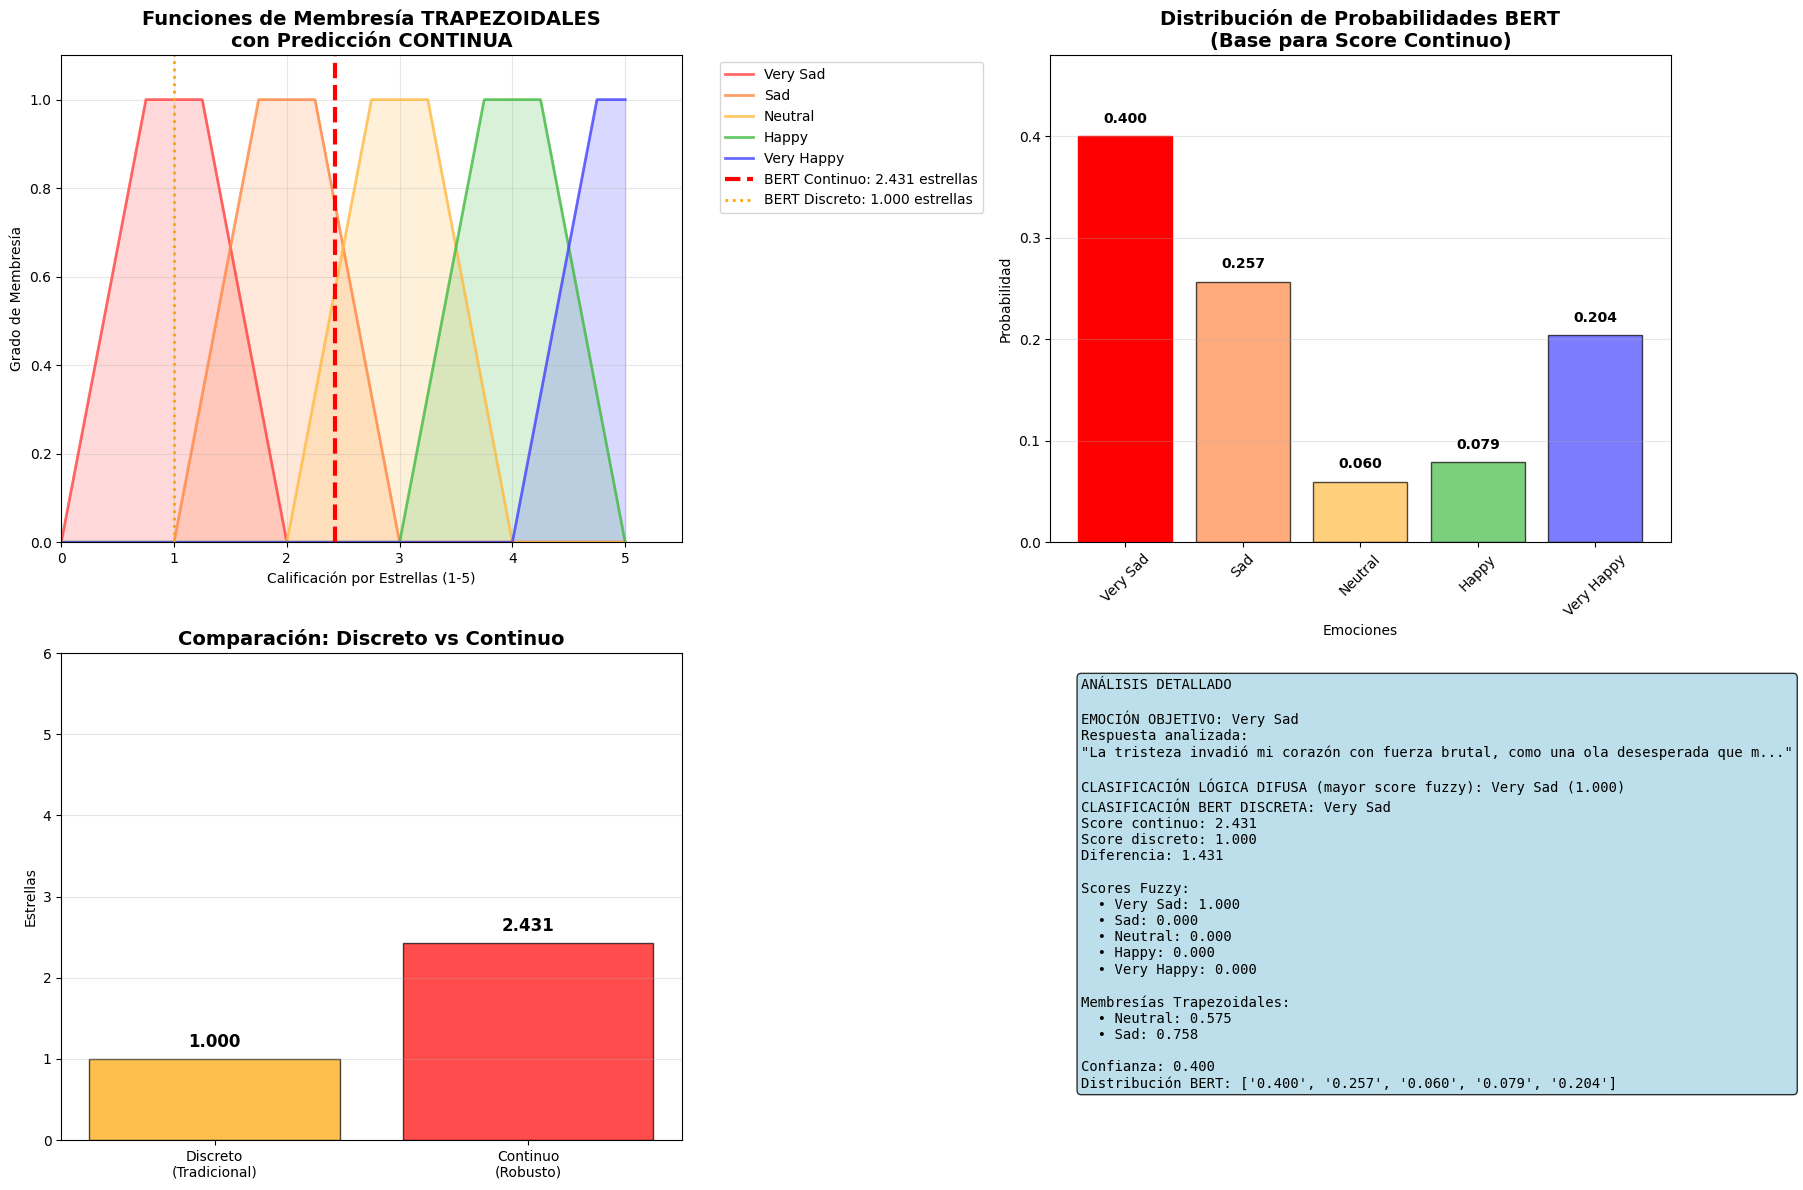

Comparación de clasificación para la frase analizada:
- Lógica difusa (mayor score fuzzy): Very Sad (1.000)
- BERT discreto (argmax): Very Sad
- Score continuo: 2.431  |  Score discreto: 1.000

Scores fuzzy (por fórmula del paper):
  • Very Sad: 1.000
  • Sad: 0.000
  • Neutral: 0.000
  • Happy: 0.000
  • Very Happy: 0.000

Membresías trapezoidales para el score continuo de BERT:
  • Neutral: 0.575
  • Sad: 0.758


In [ ]:
# =====================================================
# CELDA 7: Análisis y Visualización de Funciones Trapezoidales con Score Fuzzy
# =====================================================

def analyze_sentiment_with_bert(text):
    """Función actualizada que usa análisis robusto si está disponible"""
    try:
        if 'analyze_sentiment_with_bert_robust' in globals():
            analysis = analyze_sentiment_with_bert_robust(text)
            return {
                'emotion_index': analysis['emotion_index'],
                'confidence': analysis['confidence'],
                'label': analysis['label'],
                'all_scores': analysis['all_scores'],
                'continuous_stars': analysis['continuous_stars']
            }
        else:
            inputs = bert_tokenizer(text, return_tensors="pt", truncation=True, max_length=512)
            inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
            with torch.no_grad():
                outputs = bert_model(**inputs)
                predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
                predicted_class = torch.argmax(predictions, dim=-1).item()
                confidence = predictions.max().item()
            return {
                'emotion_index': predicted_class,
                'confidence': confidence,
                'label': f"{predicted_class + 1} stars",
                'all_scores': predictions.squeeze().tolist(),
                'continuous_stars': predicted_class + 1.0
            }
    except Exception as e:
        print(f"Error en análisis BERT: {e}")
        return {
            'emotion_index': 2,
            'confidence': 0.5,
            'label': '3 stars',
            'all_scores': [0.2, 0.2, 0.2, 0.2, 0.2],
            'continuous_stars': 3.0
        }

print("Probando análisis con BERT actualizado...")
if 'test_response' in globals():
    test_analysis = analyze_sentiment_with_bert(test_response)
else:
    test_prompt = generate_emotion_specific_prompt("Happy")
    test_response = generate_response(test_prompt)
    test_analysis = analyze_sentiment_with_bert(test_response)
print(f"Respuesta generada: {test_response[:100]}...")
print(f"Análisis BERT: {test_analysis}")

x = np.linspace(0, 5, 1000)

def trapezoidal_function(x, params):
    a, b, c, d = params
    y = np.zeros_like(x)
    mask1 = (x > a) & (x <= b)
    y[mask1] = (x[mask1] - a) / (b - a)
    mask2 = (x > b) & (x <= c)
    y[mask2] = 1.0
    mask3 = (x > c) & (x < d)
    y[mask3] = (d - x[mask3]) / (d - c)
    return y

trapezoidal_params = FUZZY_MEMBERSHIP_PARAMS
emotion_names = first_bert_labels
colors = ['#ff4444', '#ff8844', '#ffbb44', '#44bb44', '#4444ff']

fig = plt.figure(figsize=(18, 12))

# Panel 1: Funciones trapezoidales con predicción continua
ax1 = plt.subplot(2, 2, 1)
for emotion, color in zip(emotion_names, colors):
    params = trapezoidal_params[emotion]
    y = trapezoidal_function(x, params)
    ax1.plot(x, y, color=color, linewidth=2, label=emotion, alpha=0.8)
    ax1.fill_between(x, 0, y, color=color, alpha=0.2)

continuous_prediction = test_analysis.get('continuous_stars', test_analysis['emotion_index'] + 1)
ax1.axvline(continuous_prediction, color='red', linestyle='--', linewidth=3,
           label=f'BERT Continuo: {continuous_prediction:.3f} estrellas')

discrete_prediction = test_analysis['emotion_index'] + 1
if abs(continuous_prediction - discrete_prediction) > 0.1:
    ax1.axvline(discrete_prediction, color='orange', linestyle=':', linewidth=2,
               label=f'BERT Discreto: {discrete_prediction:.3f} estrellas')

ax1.set_title('Funciones de Membresía TRAPEZOIDALES\ncon Predicción CONTINUA',
             fontweight='bold', fontsize=14)
ax1.set_xlabel('Calificación por Estrellas (1-5)')
ax1.set_ylabel('Grado de Membresía')
ax1.set_xlim(0, 5.5)
ax1.set_ylim(0, 1.1)
ax1.grid(True, alpha=0.3)
ax1.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Panel 2: Distribución de probabilidades BERT
ax2 = plt.subplot(2, 2, 2)
probabilities = test_analysis['all_scores']
bars = ax2.bar(emotion_names, probabilities, color=colors, alpha=0.7, edgecolor='black')
max_prob_idx = probabilities.index(max(probabilities))
bars[max_prob_idx].set_color('red')
bars[max_prob_idx].set_alpha(1.0)
ax2.set_title('Distribución de Probabilidades BERT\n(Base para Score Continuo)',
             fontweight='bold', fontsize=14)
ax2.set_xlabel('Emociones')
ax2.set_ylabel('Probabilidad')
ax2.set_ylim(0, max(probabilities) * 1.2)
ax2.tick_params(axis='x', rotation=45)
for bar, prob in zip(bars, probabilities):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{prob:.3f}', ha='center', va='bottom', fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')

# Panel 3: Comparación Discreto vs Continuo
ax3 = plt.subplot(2, 2, 3)
methods = ['Discreto\n(Tradicional)', 'Continuo\n(Robusto)']
scores = [discrete_prediction, continuous_prediction]
colors_comp = ['orange', 'red']
bars_comp = ax3.bar(methods, scores, color=colors_comp, alpha=0.7, edgecolor='black')
ax3.set_title('Comparación: Discreto vs Continuo',
             fontweight='bold', fontsize=14)
ax3.set_ylabel('Estrellas')
ax3.set_ylim(0, 6)
for bar, score in zip(bars_comp, scores):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{score:.3f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax3.grid(True, alpha=0.3, axis='y')

# Panel 4: Información textual mejorada (con lógica difusa y score fuzzy)
ax4 = plt.subplot(2, 2, 4)
ax4.axis('off')

# Calcular el score fuzzy para cada emoción usando la fórmula exacta del paper
fuzzy_scores = {emotion: fuzzy_processor.calculate_fuzzy_score(test_analysis['emotion_index'], emotion) for emotion in emotion_names}
max_fuzzy_emotion = max(fuzzy_scores, key=fuzzy_scores.get)
max_fuzzy_score = fuzzy_scores[max_fuzzy_emotion]

# También calcular membresías trapezoidales para el score continuo
memberships = fuzzy_processor.calculate_membership_values(continuous_prediction)

discrete_emotion = emotion_names[test_analysis['emotion_index']]

info_text = f"ANÁLISIS DETALLADO\n\n"
info_text += f"EMOCIÓN OBJETIVO: {globals().get('emocion_prueba', 'No definida')}\n"
info_text += f"Respuesta analizada:\n\"{test_response[:80]}...\"\n\n"
info_text += f"CLASIFICACIÓN LÓGICA DIFUSA (mayor score fuzzy): {max_fuzzy_emotion} ({max_fuzzy_score:.3f})\n"
info_text += f"CLASIFICACIÓN BERT DISCRETA: {discrete_emotion}\n"
info_text += f"Score continuo: {continuous_prediction:.3f}\n"
info_text += f"Score discreto: {discrete_prediction:.3f}\n"
info_text += f"Diferencia: {abs(continuous_prediction - discrete_prediction):.3f}\n\n"
info_text += f"Scores Fuzzy:\n"
for emotion, score in fuzzy_scores.items():
    info_text += f"  • {emotion}: {score:.3f}\n"
info_text += f"\nMembresías Trapezoidales:\n"
for emotion, membership in memberships.items():
    if membership > 0.01:
        info_text += f"  • {emotion}: {membership:.3f}\n"
info_text += f"\nConfianza: {test_analysis['confidence']:.3f}\n"
info_text += f"Distribución BERT: {['{:.3f}'.format(x) for x in probabilities]}"

ax4.text(0.05, 0.95, info_text, transform=ax4.transAxes,
         fontsize=10, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()

# Consola comparativa
print("Comparación de clasificación para la frase analizada:")
print(f"- Lógica difusa (mayor score fuzzy): {max_fuzzy_emotion} ({max_fuzzy_score:.3f})")
print(f"- BERT discreto (argmax): {discrete_emotion}")
print(f"- Score continuo: {continuous_prediction:.3f}  |  Score discreto: {discrete_prediction:.3f}")
print("\nScores fuzzy (por fórmula del paper):")
for emotion, score in fuzzy_scores.items():
    print(f"  • {emotion}: {score:.3f}")

print("\nMembresías trapezoidales para el score continuo de BERT:")
for emotion, membership in memberships.items():
    if membership > 0.01:
        print(f"  • {emotion}: {membership:.3f}")


In [ ]:
analyze_sentiment_with_bert(test_response)

print("\n=== PASO A PASO BERT ===")
print("Token IDs:", inputs['input_ids'])
print("outputs.logits shape:", outputs.logits.shape)
print("outputs.logits (original):", outputs.logits)
print("raw_logits (squeeze):", raw_logits)
print("scaled_logits:", scaled_logits)
print("predictions (softmax):", predictions)
print("emotion_indices:", emotion_indices)
print("weighted_index:", weighted_index)
print("continuous_stars:", continuous_stars)
print("predicted_class (argmax):", predicted_class)
print("confidence (max prob):", confidence)
print("all_scores (probabilidades CPU):", all_scores)
print("raw_logits_list (CPU):", raw_logits_list)



=== PASO A PASO BERT ===
Token IDs: tensor([[  101, 10106, 71530, 10601, 10104, 16654, 10625, 11793, 28610, 10173,
         22043, 63573,   117, 10245, 10155, 36614, 83011, 53405, 11466, 10126,
         10525, 75037, 17346, 14796, 10117, 50192, 17190, 10134, 58706,   119,
         10175, 35645, 90519, 10102, 11793, 11966, 10128, 10143, 38485, 22998,
         10109, 11178, 10250, 21459,   117, 33969, 10622, 10109, 10117, 10222,
         10973, 10245, 45871, 50143, 10107, 10126, 10181, 46507, 10115,   143,
         10542, 36353, 60890, 10107,   119, 10265, 42337, 10126, 12698, 10525,
         14796, 10115, 68089,   117, 26340, 13150, 10155, 93635, 58237, 10218,
         16228, 10453,   117, 10155, 43885, 10112, 62214, 10126, 10525, 17778,
         15405, 10126, 10106, 11966, 10153, 11174, 10119, 20730, 10877, 10585,
         10639, 10109, 10117, 63781,   117, 29421, 88694, 10102, 80650, 10688,
         10106, 13019, 13007, 14605, 10951, 13518, 10126, 12466, 18312,   119,
         10117,

CELDA 7A: Prueba Rápida de Matriz de Confusión
=====================================================

Generando para emoción: Very Sad...
Respuestas de Very Sad generadas: 5/5
Generando para emoción: Sad...
Respuestas de Sad generadas: 5/5
Generando para emoción: Neutral...
Respuestas de Neutral generadas: 5/5
Generando para emoción: Happy...
Respuestas de Happy generadas: 5/5
Generando para emoción: Very Happy...
Respuestas de Very Happy generadas: 5/5

=== 1. MATRIZ DE CONFUSIÓN — MÉTODO DISCRETO (argmax BERT) ===


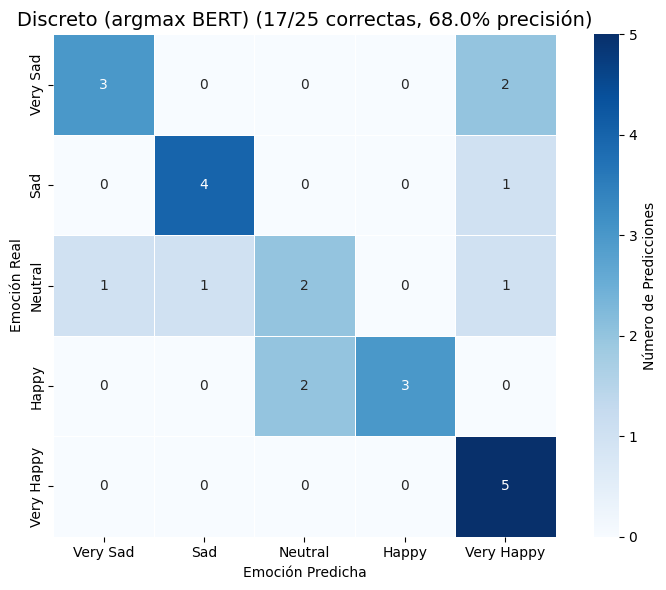

Discreto (argmax BERT): Precisión general: 68.0%  (17/25 correctas)
Precisión por emoción:
  Very Sad: 3/5 (60.0%)
  Sad: 4/5 (80.0%)
  Neutral: 2/5 (40.0%)
  Happy: 3/5 (60.0%)
  Very Happy: 5/5 (100.0%)

Reporte detallado:
              precision    recall  f1-score   support

    Very Sad      1.000     0.600     0.750         5
         Sad      0.500     0.400     0.444         5
     Neutral      0.800     0.800     0.800         5
       Happy      0.556     1.000     0.714         5
  Very Happy      0.750     0.600     0.667         5

    accuracy                          0.680        25
   macro avg      0.721     0.680     0.675        25
weighted avg      0.721     0.680     0.675        25


=== 2. MATRIZ DE CONFUSIÓN — SCORE CONTINUO (redondeo) ===


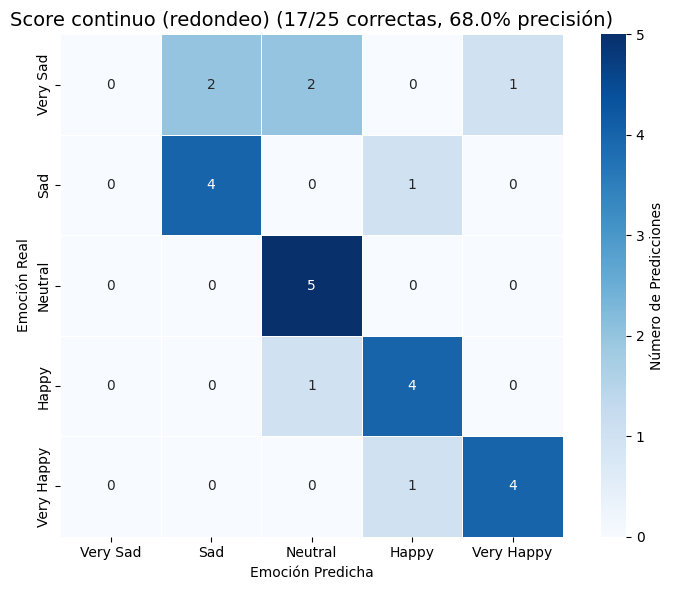

Score continuo (redondeo): Precisión general: 68.0%  (17/25 correctas)
Precisión por emoción:
  Very Sad: 0/5 (0.0%)
  Sad: 4/5 (80.0%)
  Neutral: 5/5 (100.0%)
  Happy: 4/5 (80.0%)
  Very Happy: 4/5 (80.0%)

Reporte detallado:
              precision    recall  f1-score   support

    Very Sad      0.667     0.800     0.727         5
         Sad      0.625     1.000     0.769         5
     Neutral      0.667     0.800     0.727         5
       Happy      0.800     0.800     0.800         5
  Very Happy      0.000     0.000     0.000         5

    accuracy                          0.680        25
   macro avg      0.552     0.680     0.605        25
weighted avg      0.552     0.680     0.605        25


=== 3. MATRIZ DE CONFUSIÓN — SCORE FUZZY (lógica difusa) ===


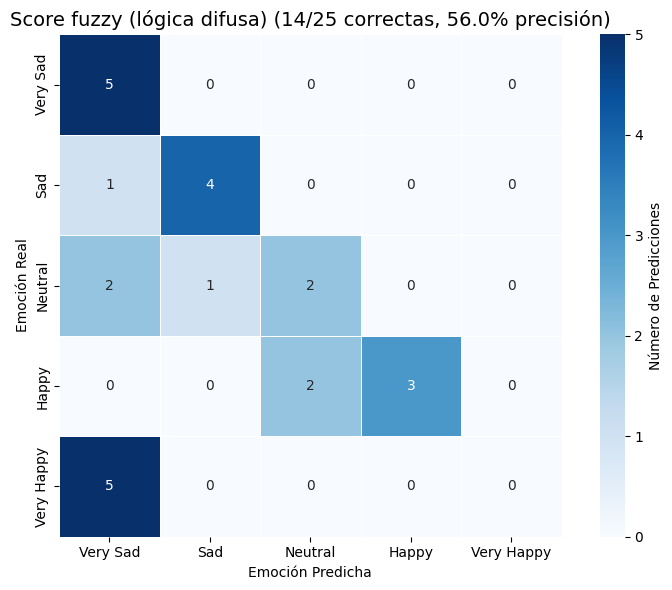

Score fuzzy (lógica difusa): Precisión general: 56.0%  (14/25 correctas)
Precisión por emoción:
  Very Sad: 5/5 (100.0%)
  Sad: 4/5 (80.0%)
  Neutral: 2/5 (40.0%)
  Happy: 3/5 (60.0%)
  Very Happy: 0/5 (0.0%)

Reporte detallado:
              precision    recall  f1-score   support

    Very Sad      1.000     0.600     0.750         5
         Sad      0.500     0.400     0.444         5
     Neutral      0.800     0.800     0.800         5
       Happy      0.000     0.000     0.000         5
  Very Happy      0.385     1.000     0.556         5

    accuracy                          0.560        25
   macro avg      0.537     0.560     0.510        25
weighted avg      0.537     0.560     0.510        25


RESUMEN:
Discreto: 68.0% | Continuo: 68.0% | Fuzzy: 56.0%


In [ ]:
def generate_test_responses_all_methods():
    """Generar 5 respuestas por emoción, clasificando por 3 métodos: discreto, continuo y fuzzy."""
    emotions = first_bert_labels
    all_responses = []
    all_true_labels = []
    pred_discrete = []
    pred_continuous = []
    pred_fuzzy = []
    has_robust = 'analyze_sentiment_with_bert_robust' in globals()

    for emotion in emotions:
        print(f"Generando para emoción: {emotion}...")
        emotion_responses = 0
        for i in range(5):
            try:
                prompt = generate_emotion_specific_prompt(emotion)
                response = generate_response(prompt, max_length=100)
                # === Análisis BERT
                if has_robust:
                    bert_analysis = analyze_sentiment_with_bert_robust(response)
                    predicted_index = bert_analysis['emotion_index']
                    continuous_stars = bert_analysis['continuous_stars']
                else:
                    inputs = bert_tokenizer(response, return_tensors="pt", truncation=True, max_length=512)
                    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
                    with torch.no_grad():
                        outputs = bert_model(**inputs)
                        predictions = torch.nn.functional.softmax(outputs.logits, dim=-1)
                        predicted_index = torch.argmax(predictions, dim=-1).item()
                        # Media ponderada para score continuo
                        emotion_indices = torch.arange(5, dtype=torch.float32, device=DEVICE)
                        weighted_index = torch.sum(predictions * emotion_indices, dim=-1).item()
                        continuous_stars = weighted_index + 1.0

                # 1. Discreto tradicional
                predicted_emotion_discrete = emotions[predicted_index]
                # 2. Score continuo (redondeo a entero más cercano, limitado a rango válido)
                idx_continuous = int(round(continuous_stars - 1))
                idx_continuous = max(0, min(len(emotions)-1, idx_continuous))
                predicted_emotion_continuous = emotions[idx_continuous]
                # 3. Score fuzzy (mayor fuzzy score usando la fórmula del paper)
                fuzzy_scores = {em: fuzzy_processor.calculate_fuzzy_score(predicted_index, em) for em in emotions}
                predicted_emotion_fuzzy = max(fuzzy_scores, key=fuzzy_scores.get)

                all_responses.append(response)
                all_true_labels.append(emotion)
                pred_discrete.append(predicted_emotion_discrete)
                pred_continuous.append(predicted_emotion_continuous)
                pred_fuzzy.append(predicted_emotion_fuzzy)
                emotion_responses += 1
            except Exception as e:
                all_responses.append(f"Respuesta fallback para {emotion}")
                all_true_labels.append(emotion)
                pred_discrete.append("Neutral")
                pred_continuous.append("Neutral")
                pred_fuzzy.append("Neutral")
        print(f"Respuestas de {emotion} generadas: {emotion_responses}/5")
    return all_responses, all_true_labels, pred_discrete, pred_continuous, pred_fuzzy

def create_clean_confusion_matrix(true_labels, predicted_labels, title="Matriz de Confusión"):
    """Crear matriz de confusión y mostrar métricas principales."""
    emotions = first_bert_labels
    cm = confusion_matrix(true_labels, predicted_labels, labels=emotions)
    total = np.sum(cm)
    correct = np.trace(cm)
    accuracy = 100 * correct / total

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotions, yticklabels=emotions,
                cbar_kws={'label': 'Número de Predicciones'}, square=True, linewidths=0.5)
    plt.title(f'{title} ({correct}/{total} correctas, {accuracy:.1f}% precisión)', fontsize=14)
    plt.xlabel('Emoción Predicha')
    plt.ylabel('Emoción Real')
    plt.tight_layout()
    plt.show()

    print(f"{title}: Precisión general: {accuracy:.1f}%  ({correct}/{total} correctas)")
    print("Precisión por emoción:")
    for i, emotion in enumerate(emotions):
        total_true = cm[i].sum()
        correct_em = cm[i, i]
        p = (100 * correct_em / total_true) if total_true else 0
        print(f"  {emotion}: {correct_em}/{total_true} ({p:.1f}%)")
    print("\nReporte detallado:")
    print(classification_report(true_labels, predicted_labels, target_names=emotions, digits=3))
    return cm, accuracy

# Ejecutar prueba rápida con los 3 métodos
prerequisites_ok = all([
    'bert_model' in globals() and bert_model is not None,
    'bert_tokenizer' in globals() and bert_tokenizer is not None,
    'generate_response' in globals(),
    'DEVICE' in globals(),
    'fuzzy_processor' in globals()
])

if prerequisites_ok:
    (responses, true_labels,
     pred_discrete, pred_continuous, pred_fuzzy) = generate_test_responses_all_methods()
    if len(responses) >= 20:
        print("\n=== 1. MATRIZ DE CONFUSIÓN — MÉTODO DISCRETO (argmax BERT) ===")
        cm1, acc1 = create_clean_confusion_matrix(true_labels, pred_discrete, "Discreto (argmax BERT)")
        print("\n=== 2. MATRIZ DE CONFUSIÓN — SCORE CONTINUO (redondeo) ===")
        cm2, acc2 = create_clean_confusion_matrix(true_labels, pred_continuous, "Score continuo (redondeo)")
        print("\n=== 3. MATRIZ DE CONFUSIÓN — SCORE FUZZY (lógica difusa) ===")
        cm3, acc3 = create_clean_confusion_matrix(true_labels, pred_fuzzy, "Score fuzzy (lógica difusa)")
        print(f"\nRESUMEN:\nDiscreto: {acc1:.1f}% | Continuo: {acc2:.1f}% | Fuzzy: {acc3:.1f}%")
    else:
        print(f"Solo {len(responses)} respuestas generadas")
else:
    print("Faltan prerrequisitos. Ejecuta las celdas previas necesarias.")


CELDA 8A: GENERACIÓNDE 125 RESPUESTAS
=====================================================

In [ ]:
def generate_125_responses():
    """
    CELDA 8A: Generación de 125 respuestas (25 por emoción).
    Solo generación, sin análisis.
    Guarda las respuestas para CELDA 8B.
    """
    emotions = ["Very Sad", "Sad", "Neutral", "Happy", "Very Happy"]
    all_responses = {}

    print("Generando 125 respuestas con LLAMA-2-7b-chat-hf (25 por emoción)...")

    total_start_time = time.time()
    for emotion in emotions:
        print(f"Generando para: {emotion}")
        responses = []
        for i in range(25):
            prompt = generate_emotion_specific_prompt(emotion)
            response = generate_response(prompt)
            responses.append(response)
            if (i + 1) % 5 == 0:
                print(f"  {i+1}/25 respuestas generadas para {emotion}")
        all_responses[emotion] = responses
        print(f"Respuestas completadas para {emotion}")

    total_elapsed = time.time() - total_start_time
    print(f"Total de respuestas generadas: {sum(len(r) for r in all_responses.values())} en {total_elapsed:.1f} segundos.")

    # Guardar respuestas en variable global para CELDA 8B
    global generated_responses
    generated_responses = all_responses

    return all_responses

generated_responses = generate_125_responses()


Generando 125 respuestas con LLAMA-2-7b-chat-hf (25 por emoción)...
Generando para: Very Sad
  5/25 respuestas generadas para Very Sad
  10/25 respuestas generadas para Very Sad
  15/25 respuestas generadas para Very Sad
  20/25 respuestas generadas para Very Sad
  25/25 respuestas generadas para Very Sad
Respuestas completadas para Very Sad
Generando para: Sad
  5/25 respuestas generadas para Sad
  10/25 respuestas generadas para Sad
  15/25 respuestas generadas para Sad
  20/25 respuestas generadas para Sad
  25/25 respuestas generadas para Sad
Respuestas completadas para Sad
Generando para: Neutral
  5/25 respuestas generadas para Neutral
  10/25 respuestas generadas para Neutral
  15/25 respuestas generadas para Neutral
  20/25 respuestas generadas para Neutral
  25/25 respuestas generadas para Neutral
Respuestas completadas para Neutral
Generando para: Happy
  5/25 respuestas generadas para Happy
  10/25 respuestas generadas para Happy
  15/25 respuestas generadas para Happy
  20/

CELDA 8B: ANÁLISIS COMPLETO DE LAS 125 RESPUESTAS
=====================================================


Discreto (argmax BERT):


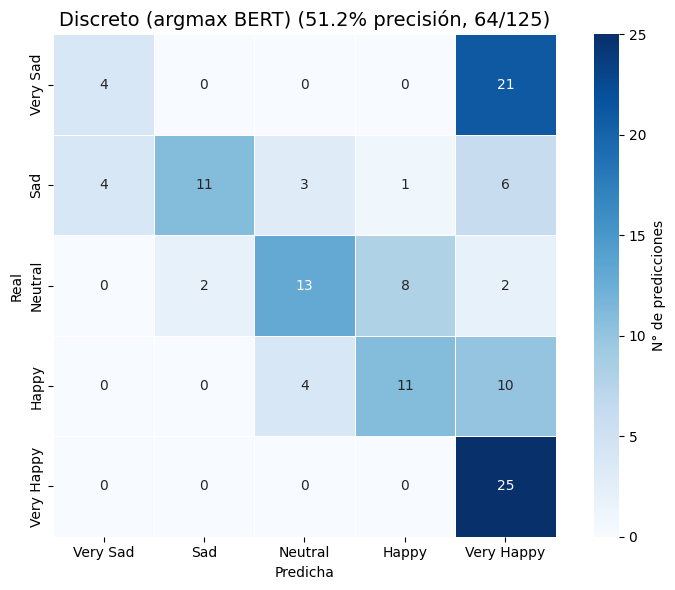

              precision    recall  f1-score   support

    Very Sad      0.550     0.440     0.489        25
         Sad      0.650     0.520     0.578        25
     Neutral      0.846     0.440     0.579        25
       Happy      0.391     1.000     0.562        25
  Very Happy      0.500     0.160     0.242        25

    accuracy                          0.512       125
   macro avg      0.587     0.512     0.490       125
weighted avg      0.587     0.512     0.490       125


Falsos Positivos (FP) y Falsos Negativos (FN):
  Very Sad   | FP:  4  | FN: 21
  Sad        | FP:  2  | FN: 14
  Neutral    | FP:  7  | FN: 12
  Happy      | FP:  9  | FN: 14
  Very Happy | FP: 39  | FN:  0
-------------------------------------------------------

Score continuo (redondeo):


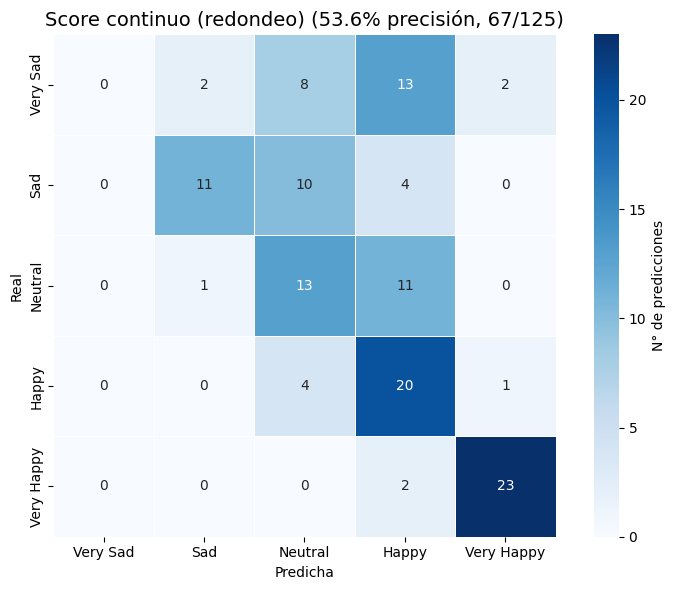

              precision    recall  f1-score   support

    Very Sad      0.400     0.800     0.533        25
         Sad      0.371     0.520     0.433        25
     Neutral      0.786     0.440     0.564        25
       Happy      0.885     0.920     0.902        25
  Very Happy      0.000     0.000     0.000        25

    accuracy                          0.536       125
   macro avg      0.488     0.536     0.487       125
weighted avg      0.488     0.536     0.487       125


Falsos Positivos (FP) y Falsos Negativos (FN):
  Very Sad   | FP:  0  | FN: 25
  Sad        | FP:  3  | FN: 14
  Neutral    | FP: 22  | FN: 12
  Happy      | FP: 30  | FN:  5
  Very Happy | FP:  3  | FN:  2
-------------------------------------------------------

Score fuzzy (lógica difusa):


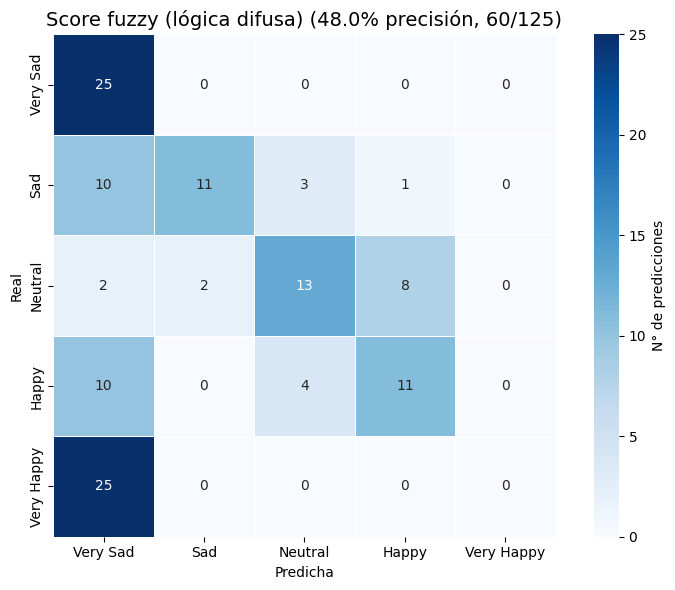

              precision    recall  f1-score   support

    Very Sad      0.550     0.440     0.489        25
         Sad      0.650     0.520     0.578        25
     Neutral      0.846     0.440     0.579        25
       Happy      0.000     0.000     0.000        25
  Very Happy      0.347     1.000     0.515        25

    accuracy                          0.480       125
   macro avg      0.479     0.480     0.432       125
weighted avg      0.479     0.480     0.432       125


Falsos Positivos (FP) y Falsos Negativos (FN):
  Very Sad   | FP: 47  | FN:  0
  Sad        | FP:  2  | FN: 14
  Neutral    | FP:  7  | FN: 12
  Happy      | FP:  9  | FN: 14
  Very Happy | FP:  0  | FN: 25
-------------------------------------------------------

RESUMEN DE PRECISIÓN: Discreto: 51.2% | Continuo: 53.6% | Fuzzy: 48.0%


In [ ]:
def analyze_125_responses_matrices(responses_data=None):
    """
    Análisis comparativo de las 125 respuestas generadas:
    - Matrices de confusión y métricas para los 3 enfoques: Discreto, Score continuo, Score fuzzy.
    """
    if responses_data is None:
        if 'generated_responses' in globals():
            responses_data = generated_responses
        else:
            print("ERROR: No hay respuestas generadas. Ejecuta CELDA 8A primero.")
            return None

    emotions = ["Very Sad", "Sad", "Neutral", "Happy", "Very Happy"]
    all_true_labels = []
    pred_discrete = []
    pred_continuous = []
    pred_fuzzy = []

    for emotion in emotions:
        responses = responses_data[emotion]
        for response in responses:
            # --- BERT analysis
            analysis = analyze_sentiment_with_bert(response)
            predicted_index = analysis['emotion_index']
            continuous_stars = analysis['continuous_stars']
            # 1. Discreto tradicional
            pred_discrete.append(emotions[predicted_index])
            # 2. Score continuo (redondeo)
            idx_continuous = int(round(continuous_stars - 1))
            idx_continuous = max(0, min(len(emotions) - 1, idx_continuous))
            pred_continuous.append(emotions[idx_continuous])
            # 3. Score fuzzy
            fuzzy_scores = {em: fuzzy_processor.calculate_fuzzy_score(predicted_index, em) for em in emotions}
            pred_fuzzy.append(max(fuzzy_scores, key=fuzzy_scores.get))
            # True label
            all_true_labels.append(emotion)

    # --- Función auxiliar de impresión
    def print_cm_metrics(y_true, y_pred, title):
        cm = confusion_matrix(y_true, y_pred, labels=emotions)
        total = np.sum(cm)
        correct = np.trace(cm)
        accuracy = 100 * correct / total
        print(f"\n{title}:")
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=emotions, yticklabels=emotions,
                    cbar_kws={'label': 'N° de predicciones'}, square=True, linewidths=0.5)
        plt.title(f'{title} ({accuracy:.1f}% precisión, {correct}/{total})', fontsize=14)
        plt.xlabel('Predicha')
        plt.ylabel('Real')
        plt.tight_layout()
        plt.show()
        print(classification_report(y_true, y_pred, target_names=emotions, digits=3))

        # --- BLOQUE: Falsos Positivos y Falsos Negativos por clase ---
        print("\nFalsos Positivos (FP) y Falsos Negativos (FN):")
        for i, emotion in enumerate(emotions):
            # FP: suma de la columna menos la diagonal
            fp = np.sum(cm[:, i]) - cm[i, i]
            # FN: suma de la fila menos la diagonal
            fn = np.sum(cm[i, :]) - cm[i, i]
            print(f"  {emotion:10} | FP: {fp:2d}  | FN: {fn:2d}")
        print("-" * 55)
        return accuracy

    acc_disc = print_cm_metrics(all_true_labels, pred_discrete, "Discreto (argmax BERT)")
    acc_cont = print_cm_metrics(all_true_labels, pred_continuous, "Score continuo (redondeo)")
    acc_fuzz = print_cm_metrics(all_true_labels, pred_fuzzy, "Score fuzzy (lógica difusa)")

    print(f"\nRESUMEN DE PRECISIÓN: Discreto: {acc_disc:.1f}% | Continuo: {acc_cont:.1f}% | Fuzzy: {acc_fuzz:.1f}%")
    return {
        'y_true': all_true_labels,
        'pred_discrete': pred_discrete,
        'pred_continuous': pred_continuous,
        'pred_fuzzy': pred_fuzzy
    }

results_125 = analyze_125_responses_matrices()


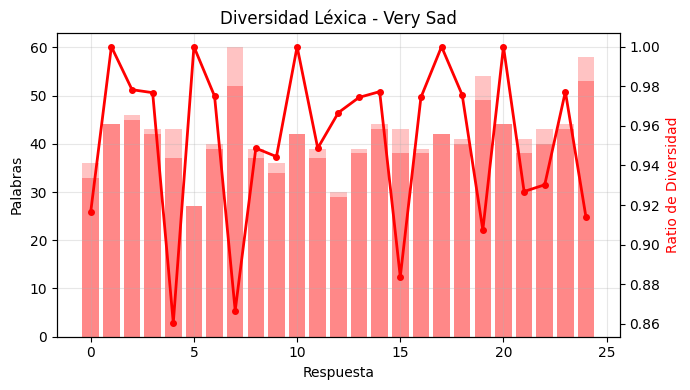

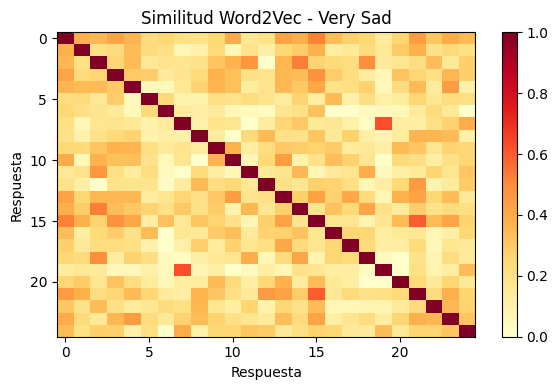

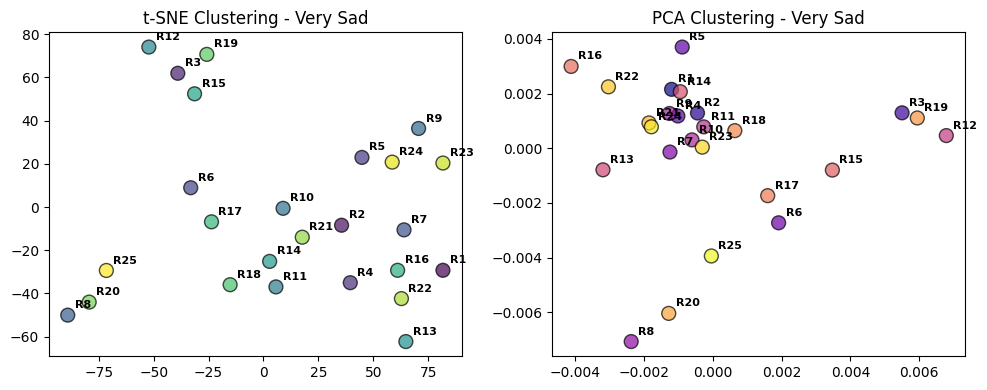

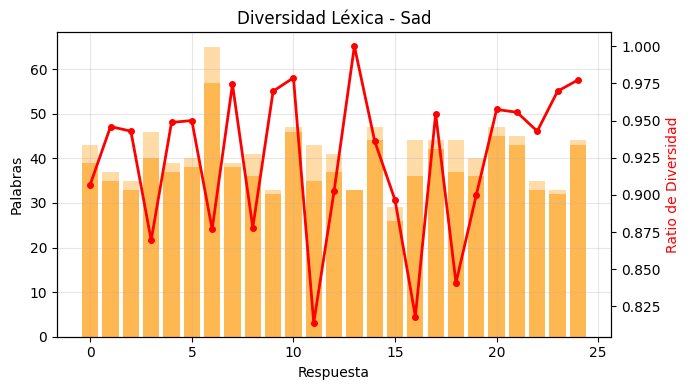

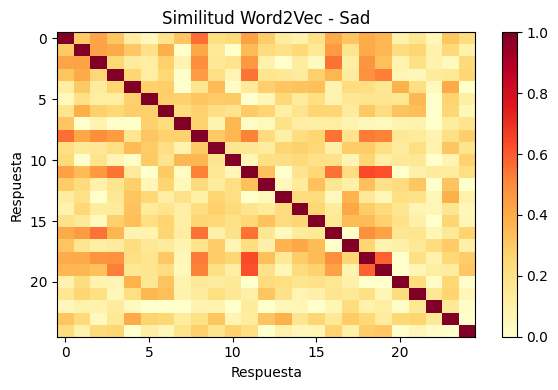

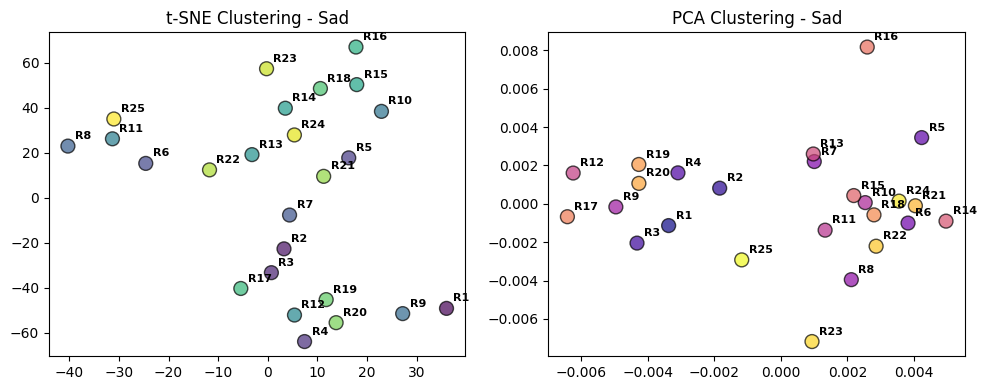

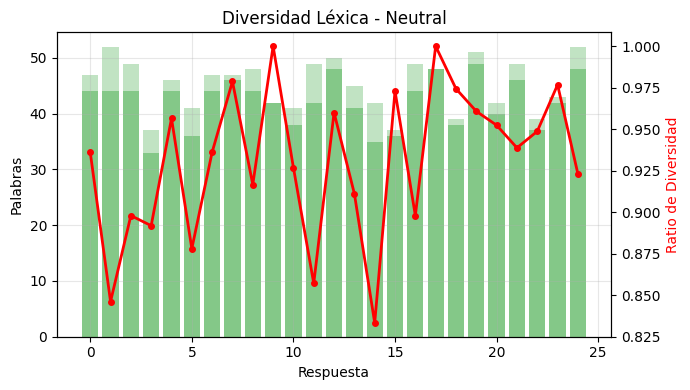

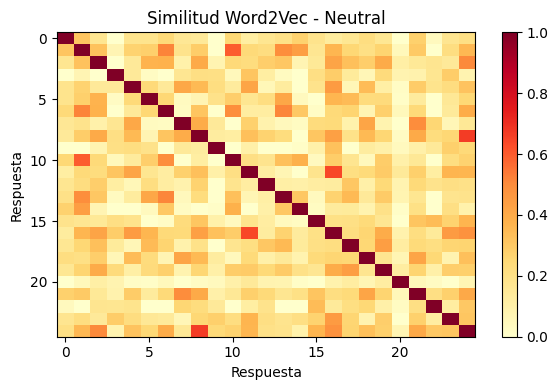

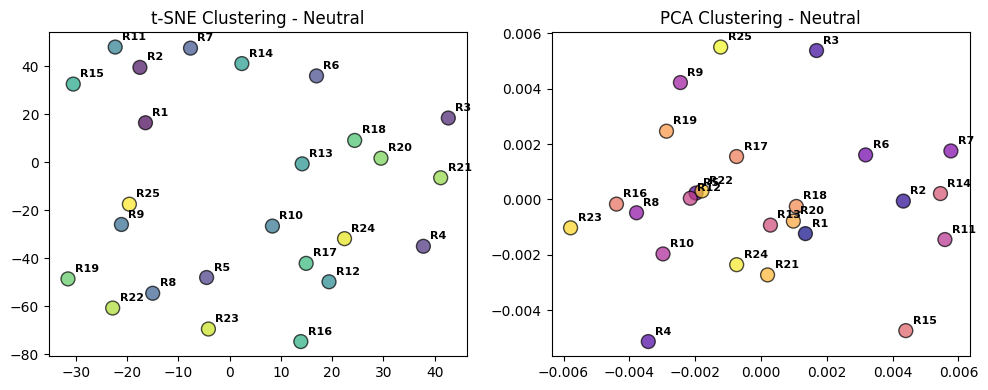

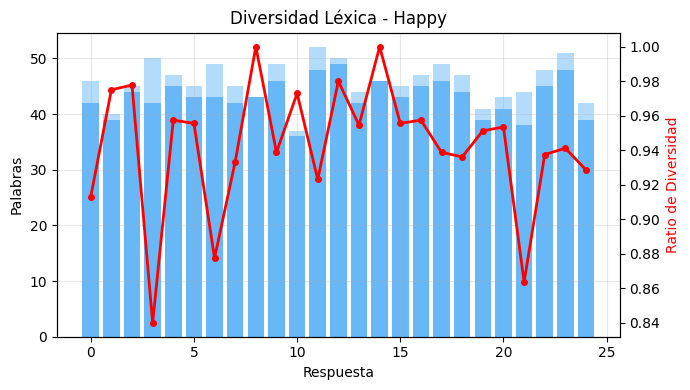

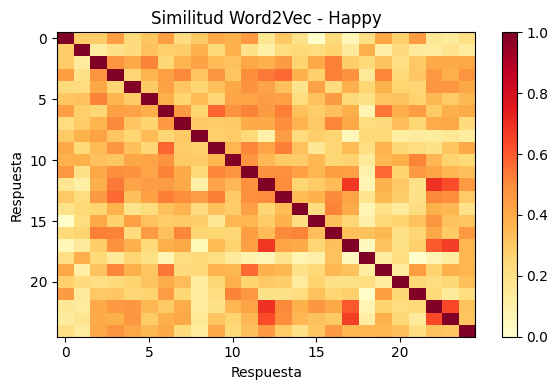

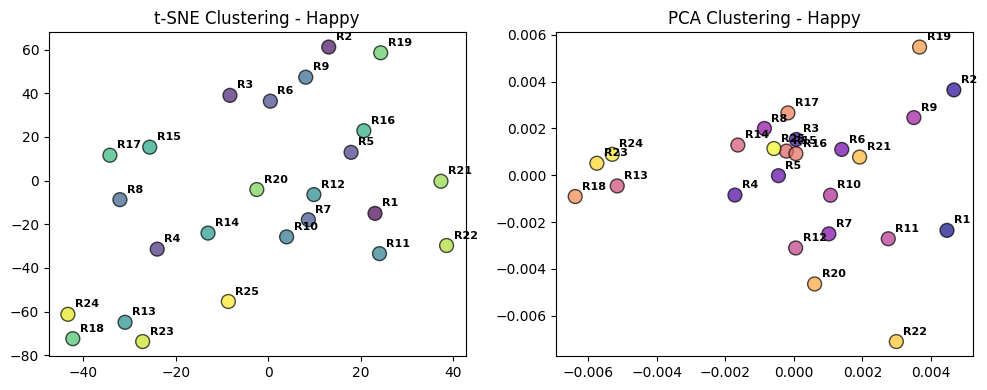

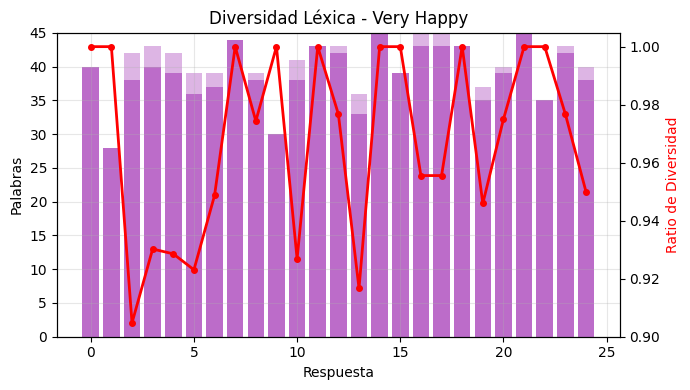

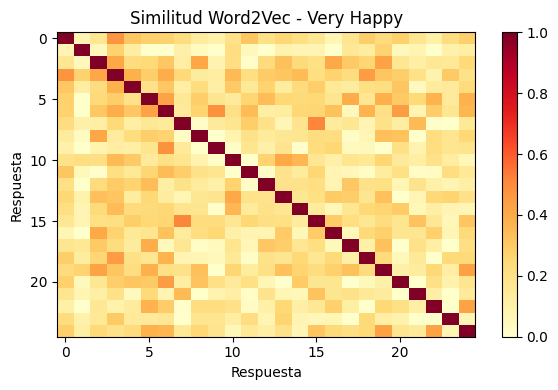

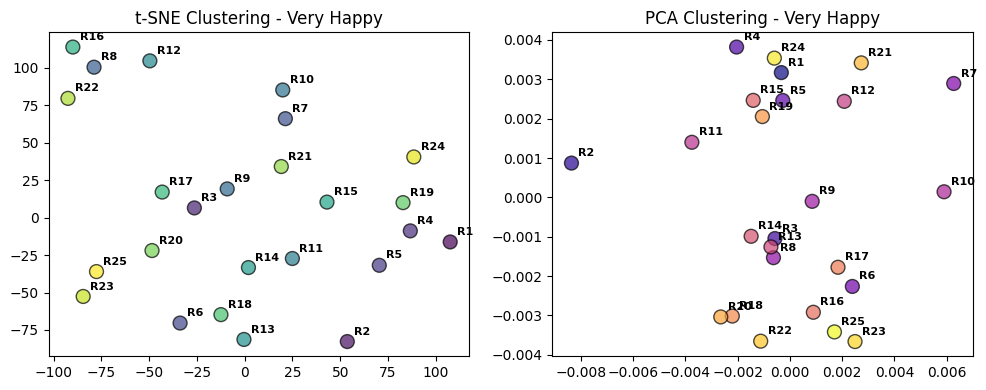


Resumen de variabilidad Word2Vec:
Very Sad  : 0.773
Sad       : 0.780
Neutral   : 0.783
Happy     : 0.674
Very Happy: 0.803
Promedio general: 0.763


In [ ]:
def analyze_125_variability(responses_data=None):
    """
    Análisis de variabilidad en las 125 respuestas generadas:
    - Diversidad léxica, similitud Word2Vec, clustering t-SNE/PCA.
    """
    if responses_data is None:
        if 'generated_responses' in globals():
            responses_data = generated_responses
        else:
            print("ERROR: No hay respuestas generadas. Ejecuta CELDA 8A primero.")
            return None

    emotions = ["Very Sad", "Sad", "Neutral", "Happy", "Very Happy"]
    from sklearn.manifold import TSNE
    from sklearn.decomposition import PCA
    from sklearn.metrics.pairwise import cosine_similarity

    variability_scores = {}
    colors = ['#ff6b6b', '#ffa726', '#66bb6a', '#42a5f5', '#ab47bc']

    for idx, emotion in enumerate(emotions):
        responses = responses_data[emotion]
        color = colors[idx]
        # --- Diversidad léxica
        word_counts, unique_counts, diversity_ratios = [], [], []
        for response in responses:
            words = preprocess_text_for_word2vec(response)
            total_words = len(words)
            unique_words = len(set(words))
            ratio = unique_words / total_words if total_words else 0
            word_counts.append(total_words)
            unique_counts.append(unique_words)
            diversity_ratios.append(ratio)
        x_pos = np.arange(len(responses))
        fig1, ax1 = plt.subplots(1, 1, figsize=(7, 4))
        ax1.bar(x_pos, unique_counts, color=color, alpha=0.8, label='Únicas')
        ax1.bar(x_pos, np.array(word_counts) - np.array(unique_counts), bottom=unique_counts, color=color, alpha=0.4, label='Repetidas')
        ax1_twin = ax1.twinx()
        ax1_twin.plot(x_pos, diversity_ratios, color='red', marker='o', linewidth=2, markersize=4, label='Diversidad')
        ax1_twin.set_ylabel('Ratio de Diversidad', color='red')
        ax1.set_title(f'Diversidad Léxica - {emotion}')
        ax1.set_xlabel('Respuesta')
        ax1.set_ylabel('Palabras')
        ax1.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
        # --- Similitudes Word2Vec
        vectors, valid_responses = [], []
        for response in responses:
            words = preprocess_text_for_word2vec(response)
            if len(words) > 0:
                word_vectors = []
                try:
                    if hasattr(calculate_text_variability_word2vec, 'model'):
                        model = calculate_text_variability_word2vec.model
                    else:
                        from gensim.models import Word2Vec
                        all_words = [preprocess_text_for_word2vec(r) for r in responses]
                        model = Word2Vec(all_words, vector_size=100, window=5, min_count=1, workers=1)
                    for word in words:
                        if word in model.wv:
                            word_vectors.append(model.wv[word])
                except:
                    pass
                if word_vectors:
                    response_vector = np.mean(word_vectors, axis=0)
                    vectors.append(response_vector)
                    valid_responses.append(response)
        if len(vectors) >= 2:
            vectors_array = np.array(vectors)
            similarity_matrix = cosine_similarity(vectors_array)
            fig2, ax2 = plt.subplots(1, 1, figsize=(6, 4))
            im = ax2.imshow(similarity_matrix, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)
            ax2.set_title(f'Similitud Word2Vec - {emotion}')
            ax2.set_xlabel('Respuesta')
            ax2.set_ylabel('Respuesta')
            plt.colorbar(im, ax=ax2)
            plt.tight_layout()
            plt.show()
        # --- Clustering t-SNE y PCA
        if len(vectors) >= 3:
            vectors_array = np.array(vectors)
            fig3, (ax3_left, ax3_right) = plt.subplots(1, 2, figsize=(10, 4))
            try:
                tsne = TSNE(n_components=2, random_state=42, perplexity=min(5, len(vectors) - 1))
                vectors_2d_tsne = tsne.fit_transform(vectors_array)
                ax3_left.scatter(vectors_2d_tsne[:, 0], vectors_2d_tsne[:, 1], c=range(len(vectors)), cmap='viridis',
                                 s=100, alpha=0.7, edgecolors='black')
                for i, (x, y) in enumerate(vectors_2d_tsne):
                    ax3_left.annotate(f'R{i+1}', (x, y), xytext=(5, 5), textcoords='offset points', fontsize=8, fontweight='bold')
                ax3_left.set_title(f't-SNE Clustering - {emotion}')
            except Exception as e:
                ax3_left.text(0.5, 0.5, f't-SNE error', ha='center', va='center', transform=ax3_left.transAxes)
            try:
                pca = PCA(n_components=2)
                vectors_2d_pca = pca.fit_transform(vectors_array)
                ax3_right.scatter(vectors_2d_pca[:, 0], vectors_2d_pca[:, 1], c=range(len(vectors)), cmap='plasma',
                                  s=100, alpha=0.7, edgecolors='black')
                for i, (x, y) in enumerate(vectors_2d_pca):
                    ax3_right.annotate(f'R{i+1}', (x, y), xytext=(5, 5), textcoords='offset points', fontsize=8, fontweight='bold')
                ax3_right.set_title(f'PCA Clustering - {emotion}')
            except Exception as e:
                ax3_right.text(0.5, 0.5, f'PCA error', ha='center', va='center', transform=ax3_right.transAxes)
            plt.tight_layout()
            plt.show()
        # --- Guardar puntuación de variabilidad
        variability = calculate_text_variability_word2vec(responses)
        variability_scores[emotion] = variability

    print("\nResumen de variabilidad Word2Vec:")
    for emotion in emotions:
        print(f"{emotion:10}: {variability_scores[emotion]:.3f}")
    print(f"Promedio general: {np.mean(list(variability_scores.values())):.3f}")

# --- USO ---
analyze_125_variability()


ANALISIS CON NUEVO MODELO
=====================================================

In [ ]:
# CELDA: INSTALAR Y CARGAR MODELO BETO DE EMOCIONES

!pip install transformers torch --quiet

from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Modelo: Emociones en Español
BETO_EMOTION_MODEL = "finiteautomata/beto-emotion-analysis"
emotion_tokenizer = AutoTokenizer.from_pretrained(BETO_EMOTION_MODEL)
emotion_model = AutoModelForSequenceClassification.from_pretrained(BETO_EMOTION_MODEL)

# Emociones posibles del modelo
emotion_labels = ['alegría', 'tristeza', 'enojo', 'miedo', 'amor', 'sorpresa', 'neutral']

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
emotion_model.to(DEVICE)

print("✅ Modelo de emociones BETO cargado")

tokenizer_config.json:   0%|          | 0.00/528 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/950 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/67.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/439M [00:00<?, ?B/s]

✅ Modelo de emociones BETO cargado


Extraccion respuestas neutras
=====================================================

In [ ]:
# EMOCIONES Y ETIQUETAS
emotions = ["Very Happy", "Happy", "Neutral", "Sad", "Very Sad"]
neutral_bert_index = 2  # Índice para "Neutral" según BERT

neutral_from_any_emotion = []

for emotion in emotions:
    responses = experiment_results['responses'][emotion]
    analyses = experiment_results['analyses'][emotion]

    for i, analysis in enumerate(analyses):
        # --- Para score continuo (enfoque robusto/continuo) ---
        idx_continuous = int(round(analysis['continuous_stars'] - 1))
        if idx_continuous == neutral_bert_index:
            neutral_from_any_emotion.append(responses[i])

print(f"✅ Total de respuestas clasificadas como 'Neutral' por score continuo: {len(neutral_from_any_emotion)}")


✅ Total de respuestas clasificadas como 'Neutral' por score continuo: 35


Agrupacion en categorias y resto del experimento
=====================================================

,Oración Filtrada,Emoción Refinada (BETO),Grupo General,Forzada como Neutral,P_alegría,P_tristeza,P_enojo,P_miedo,P_amor,P_sorpresa,P_neutral
0,Los aspectos simples de situaciones positivas ...,tristeza,miedo,False,0.200,0.789,0.004,0.001,0.003,0.001,0.001
1,Los aspectos simples de situaciones positivas ...,alegría,seguro,False,0.530,0.454,0.008,0.002,0.003,0.001,0.001
2,Las situaciones positivas regulares que pueden...,alegría,seguro,False,0.564,0.415,0.013,0.002,0.004,0.001,0.002
3,Las situaciones positivas regulares que pueden...,alegría,seguro,False,0.749,0.233,0.011,0.002,0.003,0.001,0.002
4,La rutina diaria es un flujo regular de activi...,alegría,seguro,False,0.977,0.015,0.002,0.001,0.002,0.001,0.001
5,Experiencias típicas: Durante las experiencias...,alegría,seguro,False,0.983,0.010,0.002,0.002,0.002,0.001,0.001
6,La situación de ir al trabajo es normalmente a...,alegría,seguro,False,0.967,0.022,0.005,0.001,0.002,0.001,0.002
7,Las personas suelen realizar diversas activida...,alegría,seguro,False,0.983,0.006,0.004,0.002,0.002,0.001,0.002
8,Los eventos comunes que se suelen celebrar en ...,alegría,seguro,False,0.971,0.004,0.016,0.005,0.001,0.001,0.002
9,El trabajo regular es una actividad diaria que...,alegría,seguro,False,0.975,0.017,0.002,0.001,0.003,0.001,0.002


🧠 Oraciones clasificadas como 'neutral' por baja confianza (< 0.1): 0 de 35


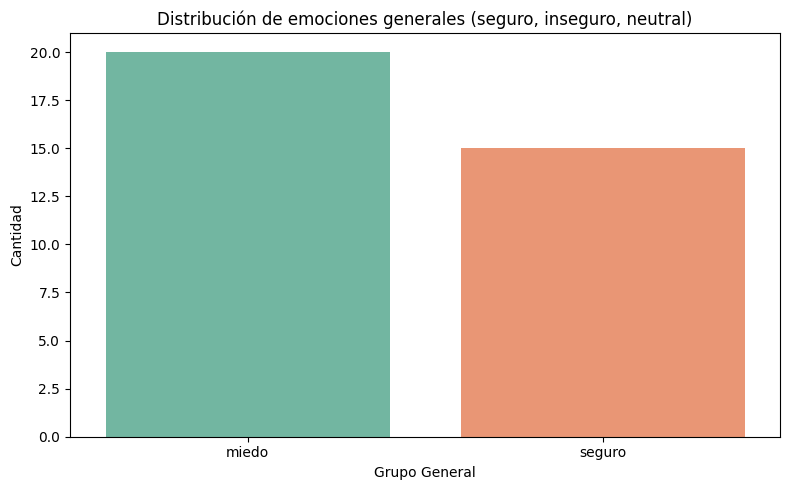

In [ ]:
# Agrupar emociones de BERT en 3 grandes categorías
def group_emotion_general(emotion):
    if emotion in ["alegría", "amor"]:
        return "seguro"
    elif emotion in ["tristeza", "enojo", "miedo"]:
        return "miedo"
    elif emotion in ["sorpresa", "neutral", "incierta"]:
        return "neutral"
    else:
        return "neutral"

# Clasificar con BETO con lógica para detectar neutralidad forzada
def predict_emotion_with_details(text, threshold=0.3, fallback_neutral_threshold=0.1):
    inputs = emotion_tokenizer(text, return_tensors="pt", truncation=True, padding=True).to(DEVICE)
    with torch.no_grad():
        outputs = emotion_model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1).squeeze().cpu().numpy()

    max_prob = probs.max()
    pred_index = probs.argmax()

    # 🔁 Lógica: neutral forzada si toda la predicción es débil
    if max_prob < fallback_neutral_threshold:
        predicted_emotion = "neutral"
        was_forced_neutral = True
    elif max_prob >= threshold:
        predicted_emotion = emotion_labels[pred_index]
        was_forced_neutral = False
    else:
        predicted_emotion = "incierta"
        was_forced_neutral = False

    general_group = group_emotion_general(predicted_emotion)
    return predicted_emotion, probs, general_group, was_forced_neutral

# Clasificar todas las oraciones
fine_emotions_filtered = []
probs_all = []
general_groups = []
forced_neutral_flags = []

for text in neutral_from_any_emotion:
    emotion, probs, group, was_forced = predict_emotion_with_details(text, threshold=0.3)
    fine_emotions_filtered.append(emotion)
    probs_all.append(probs)
    general_groups.append(group)
    forced_neutral_flags.append(was_forced)

# Crear tabla con columnas de probabilidades
import pandas as pd

df_emotions_filtered = pd.DataFrame({
    "Oración Filtrada": neutral_from_any_emotion,
    "Emoción Refinada (BETO)": fine_emotions_filtered,
    "Grupo General": general_groups,
    "Forzada como Neutral": forced_neutral_flags
})

# Agregar columnas de probabilidades por emoción
for i, label in enumerate(emotion_labels):
    df_emotions_filtered[f"P_{label}"] = [round(float(p[i]), 3) for p in probs_all]

# Mostrar tabla
from IPython.display import display
display(df_emotions_filtered)

# Conteo de casos forzados
num_forzados = sum(forced_neutral_flags)
print(f"🧠 Oraciones clasificadas como 'neutral' por baja confianza (< 0.1): {num_forzados} de {len(neutral_from_any_emotion)}")

# Gráfico de distribución por grupo general
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df_emotions_filtered, x="Grupo General", palette="Set2")
plt.title("Distribución de emociones generales (seguro, inseguro, neutral)")
plt.ylabel("Cantidad")
plt.tight_layout()
plt.show()

🧠 Clasificando SOLO las oraciones con carga emocional con el chatbot...

🟢 Oración 1: "Los aspectos simples de situaciones positivas regulares que traen sonrisas naturales y momentos agradables sin euforia son el encuentro con amigos y familiares, la realización de actividades cotidianas que se han convertido en rituales placenteros, como tomar un baño relajante o leer un buen libro en un rincón tranquilo, disfrutar de una comida deliciosa y casera, o simply enjoying the beauty of nature through a walk or a moment of contemplation. Estos momentos sencillos pero significativos pueden generar una sensación de bienestar y contentamiento natural"
   ➤ Clasificación del chatbot: alegría

🟢 Oración 2: "Los aspectos simples de situaciones positivas regulares que traen sonrisas naturales y momentos agradables sin euforia pueden ser la simple conversación con amigos o familiares, disfrutar de una buena comida casera o de un tiempo libre al aire libre, experimentar la alegría de ver a un ser que

,Emoción,Cantidad
0,neutral,12
1,tristeza,12
2,sorpresa,6
3,alegría,4
4,incierta,1


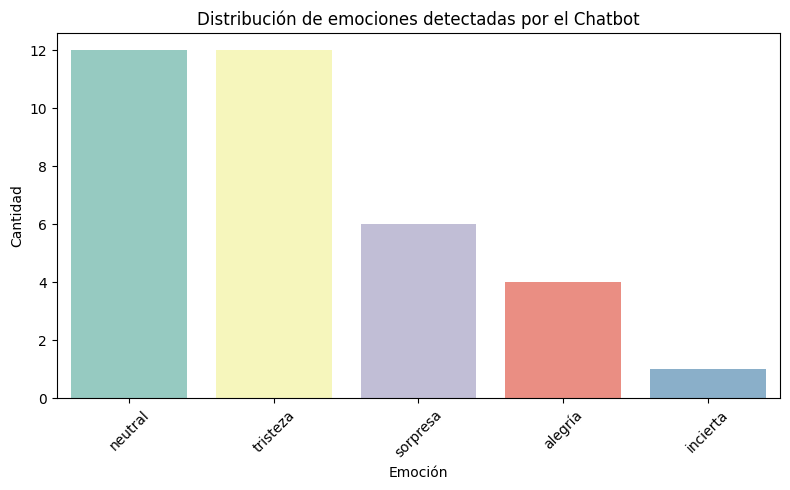

In [ ]:
# Definir las emociones posibles del modelo BETO
beto_emotion_options = ['alegría', 'tristeza', 'enojo', 'miedo', 'amor', 'sorpresa', 'neutral']

# Clasificaciones filtradas desde el chatbot
chatbot_classifications_filtered = []

def clean_emotion(text):
    text = text.lower().strip()
    for e in beto_emotion_options:
        if e in text:
            return e
    return "incierta"  # Si el chatbot devuelve algo no reconocible

print("🧠 Clasificando SOLO las oraciones con carga emocional con el chatbot...\n")

for i, text in enumerate(neutral_from_any_emotion):
    prompt = f"""
Clasifica la siguiente oración en UNA de estas emociones únicamente: {', '.join(beto_emotion_options)}.
No expliques tu respuesta. Responde solo con una palabra exacta tomada del listado.

Oración: "{text}"
Responde únicamente con una palabra correspondiente a la emoción."""

    try:
        respuesta_chatbot = generate_response(prompt)
        emocion = clean_emotion(respuesta_chatbot)
        chatbot_classifications_filtered.append(emocion)
        print(f"🟢 Oración {i+1}: \"{text}\"\n   ➤ Clasificación del chatbot: {emocion}\n")
    except Exception as e:
        chatbot_classifications_filtered.append("incierta")
        print(f"❌ Error al procesar oración {i+1}: {str(e)}")

print("✅ Clasificación completada por el chatbot usando emociones del modelo BETO.")

# === Crear tabla de conteo de emociones ===
import pandas as pd

df_chatbot = pd.DataFrame({
    "Oración": neutral_from_any_emotion,
    "Emoción Chatbot": chatbot_classifications_filtered
})

conteo_emociones = df_chatbot["Emoción Chatbot"].value_counts().reset_index()
conteo_emociones.columns = ["Emoción", "Cantidad"]

from IPython.display import display
display(conteo_emociones)

# === Gráfico de barras ===
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x="Emoción Chatbot", data=df_chatbot, palette="Set3",
              order=conteo_emociones["Emoción"])
plt.title("Distribución de emociones detectadas por el Chatbot")
plt.ylabel("Cantidad")
plt.xlabel("Emoción")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

✅ Comparando 35 pares válidos (3 grupos generales)



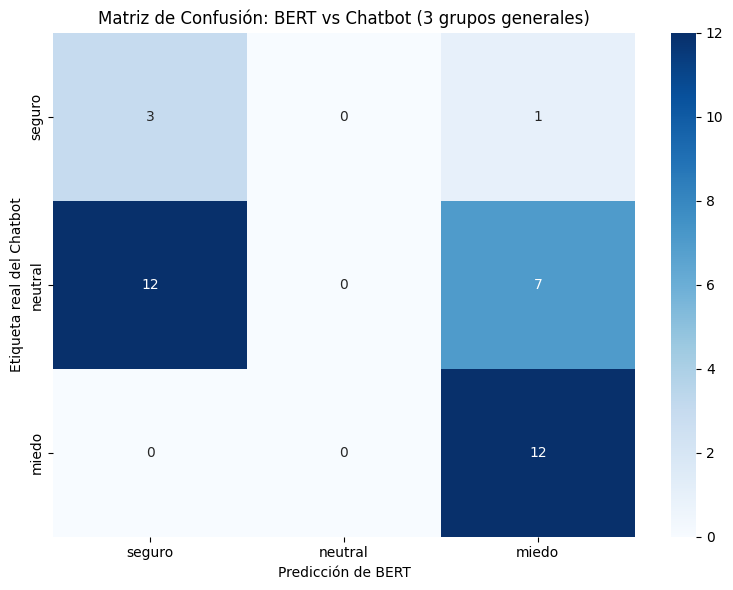

📋 Reporte de Clasificación (BERT como verdad vs Chatbot como etiqueta real):

              precision    recall  f1-score   support

      seguro       0.20      0.75      0.32         4
     neutral       0.00      0.00      0.00        19
       miedo       0.60      1.00      0.75        12

    accuracy                           0.43        35
   macro avg       0.27      0.58      0.36        35
weighted avg       0.23      0.43      0.29        35

🎯 Precisión general del sistema: 0.43
🎯 Precisión macro promedio: 0.27
🎯 F1-score macro promedio: 0.36

🔍 Falsos Positivos (FP) y Falsos Negativos (FN) por clase:
- Clase 'seguro':
   Falsos Positivos (FP): 12
   Falsos Negativos (FN): 1
- Clase 'neutral':
   Falsos Positivos (FP): 0
   Falsos Negativos (FN): 19
- Clase 'miedo':
   Falsos Positivos (FP): 8
   Falsos Negativos (FN): 0


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Agrupación común para ambos modelos
def group_emotion_general(e):
    if e in ["alegría", "amor"]:
        return "seguro"
    elif e in ["enojo", "tristeza", "miedo"]:
        return "miedo"
    elif e in ["neutral", "sorpresa", "incierta"]:
        return "neutral"
    else:
        return "neutral"

# Limpiar predicciones del chatbot
cleaned_chatbot = [group_emotion_general(clean_emotion(e)) for e in chatbot_classifications_filtered]

# Limpiar predicciones de BERT
cleaned_bert = [group_emotion_general(clean_emotion(e)) for e in fine_emotions_filtered]

# Filtrar pares válidos (solo los que están en las 3 categorías)
final_labels = ['seguro', 'neutral', 'miedo']
filtered_true = []
filtered_pred = []

for real, pred in zip(cleaned_chatbot, cleaned_bert):
    if real in final_labels and pred in final_labels:
        filtered_true.append(real)
        filtered_pred.append(pred)

print(f"✅ Comparando {len(filtered_true)} pares válidos (3 grupos generales)\n")

# Matriz de confusión 3x3
cm = confusion_matrix(filtered_true, filtered_pred, labels=final_labels)

# Mostrar matriz
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=final_labels, yticklabels=final_labels)
plt.title("Matriz de Confusión: BERT vs Chatbot (3 grupos generales)")
plt.xlabel("Predicción de BERT")
plt.ylabel("Etiqueta real del Chatbot")
plt.tight_layout()
plt.show()

# Reporte de clasificación como string (para visualización)
print("📋 Reporte de Clasificación (BERT como verdad vs Chatbot como etiqueta real):\n")
print(classification_report(filtered_true, filtered_pred, labels=final_labels, target_names=final_labels))

# Ahora, obtener métricas como dict para procesamiento
report_dict = classification_report(filtered_true, filtered_pred, labels=final_labels, target_names=final_labels, output_dict=True)

# Métricas clave
accuracy = accuracy_score(filtered_true, filtered_pred)
print(f"🎯 Precisión general del sistema: {accuracy:.2f}")
print(f"🎯 Precisión macro promedio: {report_dict['macro avg']['precision']:.2f}")
print(f"🎯 F1-score macro promedio: {report_dict['macro avg']['f1-score']:.2f}")

# --- SOLO AGREGADO: FP y FN por clase ---
print("\n🔍 Falsos Positivos (FP) y Falsos Negativos (FN) por clase:")
for i, label in enumerate(final_labels):
    FP = np.sum(cm[:, i]) - cm[i, i]
    FN = np.sum(cm[i, :]) - cm[i, i]
    print(f"- Clase '{label}':")
    print(f"   Falsos Positivos (FP): {FP}")
    print(f"   Falsos Negativos (FN): {FN}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 590.6/590.6 kB 48.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 117.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.3.2 which is incompatible.
scipy 1.13.1 requires numpy<2.3,>=1.22.4, but you have numpy 2.3.2 which is incompatible.
tensorflow 2.18.0 requires numpy<2.1.0,>=1.26.0, but you have numpy 2.3.2 which is incompatible.
opencv-contrib-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have numpy 2.3.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.3.2 which is incompatible.
opencv-python 4.12.0.88 requires numpy<2.3.0,>=2; python_version >= "3.9", but you have 

,Oración,Emoción Robertuito,P_alegría,P_tristeza,P_enojo,P_miedo,P_amor,P_sorpresa,P_neutral
0,Los aspectos simples de situaciones positivas ...,alegría,0.668,0.007,0.002,0.001,0.0,0.001,0.321
1,Los aspectos simples de situaciones positivas ...,alegría,0.494,0.010,0.002,0.001,0.0,0.001,0.492
2,Las situaciones positivas regulares que pueden...,alegría,0.870,0.006,0.001,0.001,0.0,0.001,0.121
3,Las situaciones positivas regulares que pueden...,neutral,0.316,0.008,0.001,0.001,0.0,0.001,0.673
4,La rutina diaria es un flujo regular de activi...,neutral,0.007,0.001,0.001,0.000,0.0,0.001,0.991
5,Experiencias típicas: Durante las experiencias...,neutral,0.001,0.001,0.001,0.000,0.0,0.001,0.996
6,La situación de ir al trabajo es normalmente a...,neutral,0.001,0.025,0.004,0.001,0.0,0.000,0.968
7,Las personas suelen realizar diversas activida...,neutral,0.001,0.002,0.001,0.000,0.0,0.001,0.995
8,Los eventos comunes que se suelen celebrar en ...,neutral,0.001,0.013,0.003,0.001,0.0,0.001,0.982
9,El trabajo regular es una actividad diaria que...,neutral,0.005,0.001,0.001,0.001,0.0,0.001,0.991


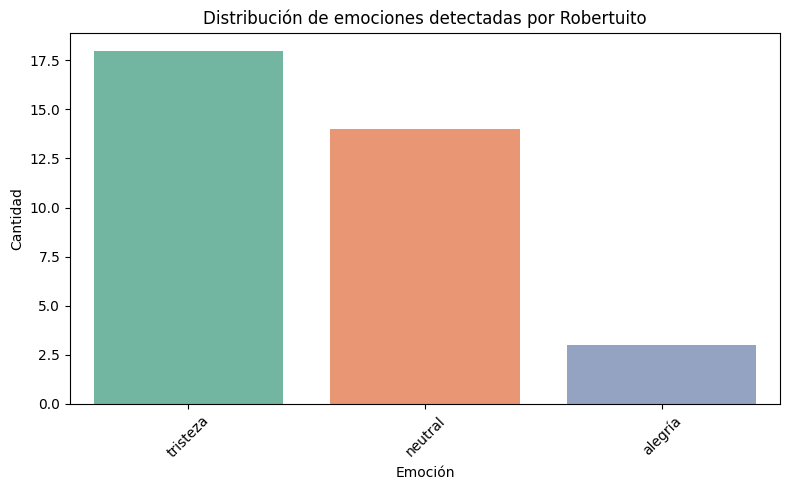

In [ ]:
# === Implementar modelo pysentimiento/robertuito-emotion ===

!pip install pysentimiento --quiet
from pysentimiento import create_analyzer

# Crear analizador de emociones en español
analyzer_robertuito = create_analyzer(task="emotion", lang="es")

# Diccionario para traducir etiquetas de emociones a español
translate_emotions = {
    "joy": "alegría",
    "sadness": "tristeza",
    "anger": "enojo",
    "fear": "miedo",
    "love": "amor",
    "surprise": "sorpresa",
    "others": "neutral"
}

robertuito_predictions = []
robertuito_probs = []

print("🧠 Clasificando oraciones con robertuito-emotion...\n")

for text in neutral_from_any_emotion:
    result = analyzer_robertuito.predict(text)
    emotion_es = translate_emotions.get(result.output, result.output)
    robertuito_predictions.append(emotion_es)
    robertuito_probs.append(result.probas)
    print(f"🟢 Oración: \"{text}\"\n   ➤ Emoción detectada: {emotion_es}\n   ➤ Probabilidades: {result.probas}\n")

# Crear DataFrame con emociones traducidas
import pandas as pd

df_robertuito = pd.DataFrame({
    "Oración": neutral_from_any_emotion,
    "Emoción Robertuito": robertuito_predictions
})

# Añadir probabilidades traducidas
for eng_label, esp_label in translate_emotions.items():
    df_robertuito[f"P_{esp_label}"] = [round(float(p.get(eng_label, 0)), 3) for p in robertuito_probs]

from IPython.display import display
display(df_robertuito)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.countplot(x="Emoción Robertuito", data=df_robertuito, palette="Set2",
              order=df_robertuito["Emoción Robertuito"].value_counts().index)
plt.title("Distribución de emociones detectadas por Robertuito")
plt.ylabel("Cantidad")
plt.xlabel("Emoción")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

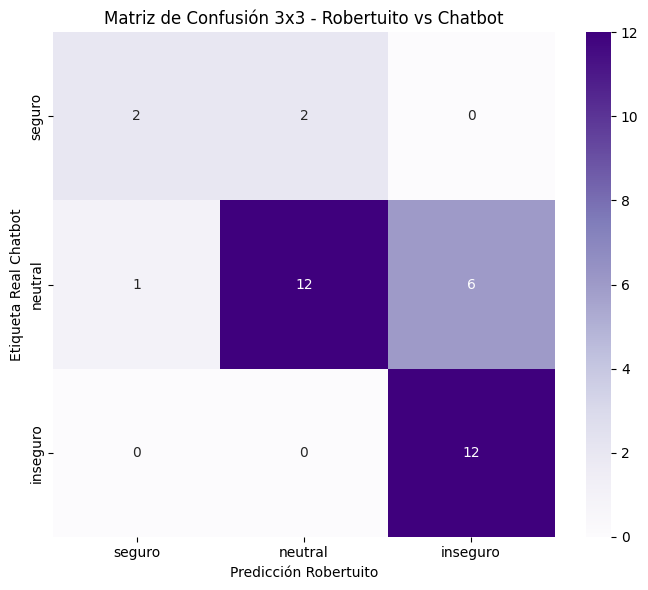

📋 Reporte de Clasificación (Robertuito vs Chatbot):

              precision    recall  f1-score   support

      seguro       0.67      0.50      0.57         4
     neutral       0.86      0.63      0.73        19
    inseguro       0.67      1.00      0.80        12

    accuracy                           0.74        35
   macro avg       0.73      0.71      0.70        35
weighted avg       0.77      0.74      0.73        35

🎯 Precisión General (Accuracy): 0.74
🎯 Precisión macro promedio: 0.73
🎯 F1-score macro promedio: 0.70

🔍 Falsos Positivos (FP) y Falsos Negativos (FN) por clase:
- Clase 'seguro':
   Falsos Positivos (FP): 1
   Falsos Negativos (FN): 2
- Clase 'neutral':
   Falsos Positivos (FP): 2
   Falsos Negativos (FN): 7
- Clase 'inseguro':
   Falsos Positivos (FP): 6
   Falsos Negativos (FN): 0


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# === Mapear las emociones de Robertuito a los 3 grupos generales ===
def map_robertuito_to_general(e):
    if e in ["alegría", "amor"]:
        return "seguro"
    elif e in ["tristeza", "enojo", "miedo"]:
        return "inseguro"
    elif e in ["neutral", "sorpresa"]:
        return "neutral"
    else:
        return "neutral"

# === Mapear las emociones del chatbot a los mismos 3 grupos ===
def map_chatbot_to_general(e):
    if e in ["alegría", "amor"]:
        return "seguro"
    elif e in ["tristeza", "enojo", "miedo"]:
        return "inseguro"
    elif e in ["neutral", "sorpresa", "incierta"]:
        return "neutral"
    else:
        return "neutral"

# Convertir predicciones de Robertuito a los grupos generales
robertuito_general = [map_robertuito_to_general(e) for e in robertuito_predictions]

# Convertir etiquetas reales (chatbot) a los mismos grupos generales
chatbot_general = [map_chatbot_to_general(e) for e in chatbot_classifications_filtered]

# Definir las clases finales
final_labels = ['seguro', 'neutral', 'inseguro']

# Generar matriz de confusión
cm = confusion_matrix(chatbot_general, robertuito_general, labels=final_labels)

plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=final_labels, yticklabels=final_labels)
plt.title("Matriz de Confusión 3x3 - Robertuito vs Chatbot")
plt.xlabel("Predicción Robertuito")
plt.ylabel("Etiqueta Real Chatbot")
plt.tight_layout()
plt.show()

# Reporte de clasificación en formato diccionario y texto
report_dict = classification_report(chatbot_general, robertuito_general, labels=final_labels, target_names=final_labels, output_dict=True)
report_text = classification_report(chatbot_general, robertuito_general, labels=final_labels, target_names=final_labels)

print("📋 Reporte de Clasificación (Robertuito vs Chatbot):\n")
print(report_text)

# Métricas principales
acc = accuracy_score(chatbot_general, robertuito_general)
precision_macro = report_dict["macro avg"]["precision"]
f1_macro = report_dict["macro avg"]["f1-score"]

print(f"🎯 Precisión General (Accuracy): {acc:.2f}")
print(f"🎯 Precisión macro promedio: {precision_macro:.2f}")
print(f"🎯 F1-score macro promedio: {f1_macro:.2f}")

# --- FP y FN por clase ---
print("\n🔍 Falsos Positivos (FP) y Falsos Negativos (FN) por clase:")
for i, label in enumerate(final_labels):
    FP = np.sum(cm[:, i]) - cm[i, i]
    FN = np.sum(cm[i, :]) - cm[i, i]
    print(f"- Clase '{label}':")
    print(f"   Falsos Positivos (FP): {FP}")
    print(f"   Falsos Negativos (FN): {FN}")


CELDA 9: EXPORTAR CSV CON VALORES PROBABILÍSTICOS DE BERT
=====================================================

In [ ]:
def create_bert_probabilities_csv(experiment_results):
    """
    Crear CSV con todos los valores probabilísticos de BERT
    para análisis detallado de las 125 respuestas,
    con columnas para predicción discreta, continua y fuzzy.
    """
    print("\n📊 CREANDO CSV CON VALORES PROBABILÍSTICOS DE BERT Y PREDICCIONES AVANZADAS...")
    print("=" * 70)

    emotions = ["Very Sad", "Sad", "Neutral", "Happy", "Very Happy"]
    all_bert_data = []

    for emotion in emotions:
        analyses = experiment_results['analyses'][emotion]
        responses = experiment_results['responses'][emotion]
        fuzzy_scores = experiment_results['fuzzy_scores'][emotion]

        for i, (analysis, response, fuzzy_score) in enumerate(zip(analyses, responses, fuzzy_scores)):
            probabilities = analysis['all_scores']

            # Score continuo (redondeado)
            continuous_stars = analysis['continuous_stars']
            idx_continuous = int(round(continuous_stars - 1))
            idx_continuous = max(0, min(len(emotions) - 1, idx_continuous))

            # Score fuzzy: buscar emoción con mayor fuzzy score
            fuzzy_score_dict = {em: fuzzy_processor.calculate_fuzzy_score(analysis['emotion_index'], em) for em in emotions}
            fuzzy_pred_label = max(fuzzy_score_dict, key=fuzzy_score_dict.get)
            fuzzy_pred_index = emotions.index(fuzzy_pred_label)

            bert_data = {
                'response_id': f"{emotion}_{i+1}",
                'target_emotion': emotion,
                'response_text': response,
                'response_length': len(response),

                # Predicción BERT (discreta, argmax)
                'bert_prediction_index': analysis['emotion_index'],
                'bert_prediction_label': emotions[analysis['emotion_index']],
                'bert_confidence': analysis['confidence'],

                # Predicción Score Continuo (redondeado)
                'continuous_stars': continuous_stars,
                'continuous_prediction_index': idx_continuous,
                'continuous_prediction_label': emotions[idx_continuous],

                # Predicción Fuzzy
                'fuzzy_prediction_index': fuzzy_pred_index,
                'fuzzy_prediction_label': fuzzy_pred_label,

                # Probabilidades BERT (en orden real)
                'prob_very_sad': probabilities[0],
                'prob_sad': probabilities[1],
                'prob_neutral': probabilities[2],
                'prob_happy': probabilities[3],
                'prob_very_happy': probabilities[4],

                # Análisis adicional
                'fuzzy_score_for_target': fuzzy_score,
                'is_correct_prediction_discrete': (analysis['emotion_index'] == emotions.index(emotion)),
                'is_correct_prediction_continuous': (idx_continuous == emotions.index(emotion)),
                'is_correct_prediction_fuzzy': (fuzzy_pred_index == emotions.index(emotion)),

                # Estadísticas de probabilidades
                'prob_max': max(probabilities),
                'prob_min': min(probabilities),
                'prob_std': np.std(probabilities),
                'prob_entropy': -sum(p * np.log(p + 1e-10) for p in probabilities),  # Entropía

                # Diferencia entre predicción y objetivo
                'prob_target_emotion': probabilities[emotions.index(emotion)],
                'prob_diff_target_vs_predicted': probabilities[emotions.index(emotion)] - probabilities[analysis['emotion_index']]
            }

            all_bert_data.append(bert_data)

    # Crear DataFrame
    df_bert = pd.DataFrame(all_bert_data)

    # Guardar CSV
    csv_filename = 'bert_probabilities_complete.csv'
    df_bert.to_csv(csv_filename, index=False)

    print(f"✅ CSV creado: {csv_filename}")
    print(f"📊 Total de registros: {len(df_bert)}")
    print(f"📋 Columnas incluidas: {len(df_bert.columns)}")

    # Mostrar estadísticas resumidas para los 3 enfoques
    print("\n📈 ESTADÍSTICAS DE PROBABILIDADES BERT Y PREDICCIONES:")
    print("-" * 60)
    for emotion in emotions:
        emotion_data = df_bert[df_bert['target_emotion'] == emotion]
        print(f"\n{emotion} ({len(emotion_data)} respuestas):")
        print(f"  Confianza BERT promedio: {emotion_data['bert_confidence'].mean():.3f}")
        print(f"  Probabilidad objetivo promedio: {emotion_data['prob_target_emotion'].mean():.3f}")
        print(f"  Entropía promedio: {emotion_data['prob_entropy'].mean():.3f}")
        print(f"  Predicciones correctas Discreto: {emotion_data['is_correct_prediction_discrete'].sum()}/{len(emotion_data)}")
        print(f"  Predicciones correctas Continuo: {emotion_data['is_correct_prediction_continuous'].sum()}/{len(emotion_data)}")
        print(f"  Predicciones correctas Fuzzy:    {emotion_data['is_correct_prediction_fuzzy'].sum()}/{len(emotion_data)}")

    # Mostrar muestra del CSV
    print(f"\n📋 MUESTRA DEL CSV (primeras 3 filas):")
    print("-" * 80)
    sample_columns = [
        'response_id', 'target_emotion', 'bert_prediction_label',
        'continuous_prediction_label', 'fuzzy_prediction_label',
        'prob_very_sad', 'prob_sad', 'prob_neutral', 'prob_happy', 'prob_very_happy'
    ]
    print(df_bert[sample_columns].head(3).to_string(index=False))

    print(f"\n💾 ARCHIVO GUARDADO: {csv_filename}")
    print("🔍 Contiene TODOS los valores probabilísticos de BERT y predicciones para análisis detallado")

    return df_bert, csv_filename
